In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

ROOT         = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_PATH   = os.path.join(ROOT, "genres_stems")
ESC50_PATH   = os.path.join(ROOT, "ESC-50-master")
MASHUP_PATH  = os.path.join(ROOT, "mashups")
TEST_CSV     = os.path.join(ROOT, "test.csv")

GENRES = ["blues", "classical", "country", "disco",
          "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

STEMS  = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]
SR     = 22050

sns.set_theme(style="darkgrid", palette="muted")

from kaggle_secrets import UserSecretsClient
import os
import wandb

user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")


wandb.login()

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

True

In [2]:
def build_inventory():
    records = []

    for genre in GENRES:
        genre_path = os.path.join(STEMS_PATH, genre)
        songs = sorted([s for s in os.listdir(genre_path)
                        if os.path.isdir(os.path.join(genre_path, s))])

        for song in songs:
            song_path = os.path.join(genre_path, song)
            for stem in STEMS:
                fpath = os.path.join(song_path, stem)
                size  = os.path.getsize(fpath) if os.path.exists(fpath) else None

                records.append({
                    "genre":    genre,
                    "song":     song,
                    "stem":     stem.replace(".wav", ""),
                    "exists":   os.path.exists(fpath),
                    "size_kb":  round(size / 1024, 2) if size else 0,
                    "path":     fpath if os.path.exists(fpath) else None,
                })

    return pd.DataFrame(records)


inventory = build_inventory()

print("=== INVENTORY SUMMARY ===")
print(f"Total stem files expected  : {len(GENRES) * 100 * 4}")
print(f"Total stem files present   : {inventory['exists'].sum()}")
print(f"Missing files              : {(~inventory['exists']).sum()}")
print(f"Zero-byte / corrupted      : {(inventory['size_kb'] == 0).sum()}")
print(f"\nFiles by genre:\n{inventory.groupby('genre')['exists'].sum()}")

=== INVENTORY SUMMARY ===
Total stem files expected  : 4000
Total stem files present   : 4000
Missing files              : 0
Zero-byte / corrupted      : 0

Files by genre:
genre
blues        400
classical    400
country      400
disco        400
hiphop       400
jazz         400
metal        400
pop          400
reggae       400
rock         400
Name: exists, dtype: int64


In [3]:
inventory.groupby(["genre", "song"])["exists"].sum().value_counts()

exists
4    1000
Name: count, dtype: int64

among these 1000 songs, every song has exactly four stems

In [4]:
inventory[inventory["exists"] == False].groupby("stem").size()

Series([], dtype: int64)

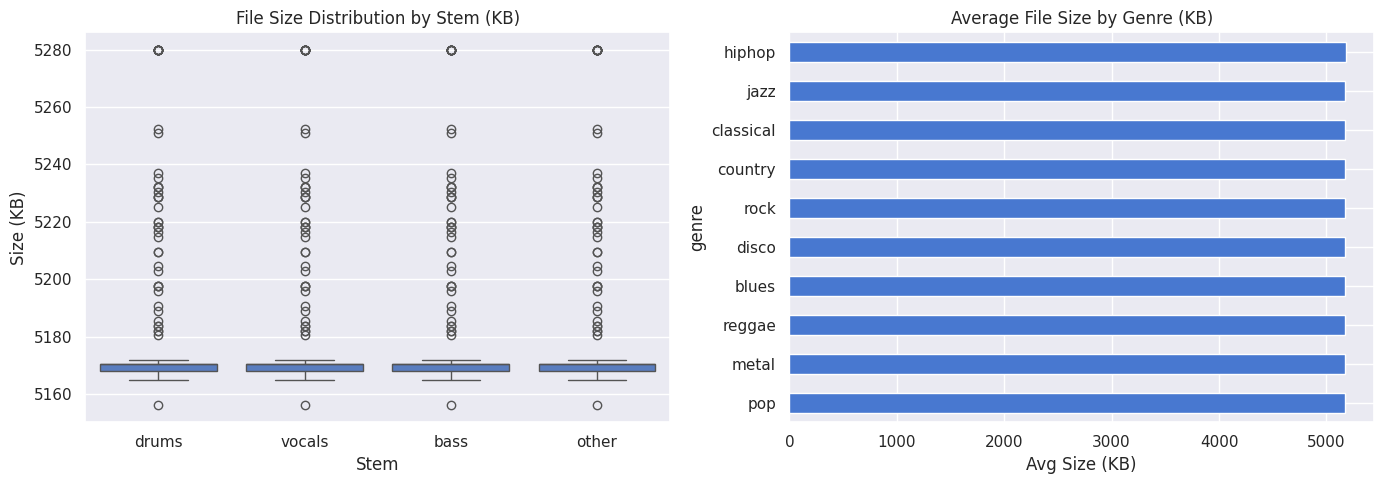

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = inventory[inventory["exists"] & (inventory["size_kb"] > 0)]

sns.boxplot(data=valid, x="stem", y="size_kb", ax=axes[0])
axes[0].set_title("File Size Distribution by Stem (KB)")
axes[0].set_xlabel("Stem")
axes[0].set_ylabel("Size (KB)")

size_means = valid.groupby("genre")["size_kb"].mean().sort_values()
size_means.plot(kind="barh", ax=axes[1])
axes[1].set_title("Average File Size by Genre (KB)")
axes[1].set_xlabel("Avg Size (KB)")

plt.tight_layout()
plt.savefig("file_size_distribution.png", dpi=150)
plt.show()

100%|██████████| 4000/4000 [07:44<00:00,  8.62it/s]



=== UNIQUE SAMPLE RATES ===
[44100]

=== DURATION STATS (seconds) ===
         count   mean   std    min   25%    50%    75%    max
stem                                                         
bass    1000.0  30.02  0.08  29.93  30.0  30.01  30.01  30.65
drums   1000.0  30.02  0.08  29.93  30.0  30.01  30.01  30.65
other   1000.0  30.02  0.08  29.93  30.0  30.01  30.01  30.65
vocals  1000.0  30.02  0.08  29.93  30.0  30.01  30.01  30.65

=== PEAK dB STATS ===
         count   mean    std     min    25%    50%   75%  max
stem                                                         
bass    1000.0 -14.52  15.27 -200.00 -15.34 -11.02 -7.82  0.0
drums   1000.0 -10.37  17.24  -90.31  -9.92  -4.28 -0.96 -0.0
other   1000.0  -8.33   4.60  -30.30 -10.71  -7.88 -4.94 -0.0
vocals  1000.0 -12.49  18.25  -90.31 -10.42  -5.48 -2.49  0.0


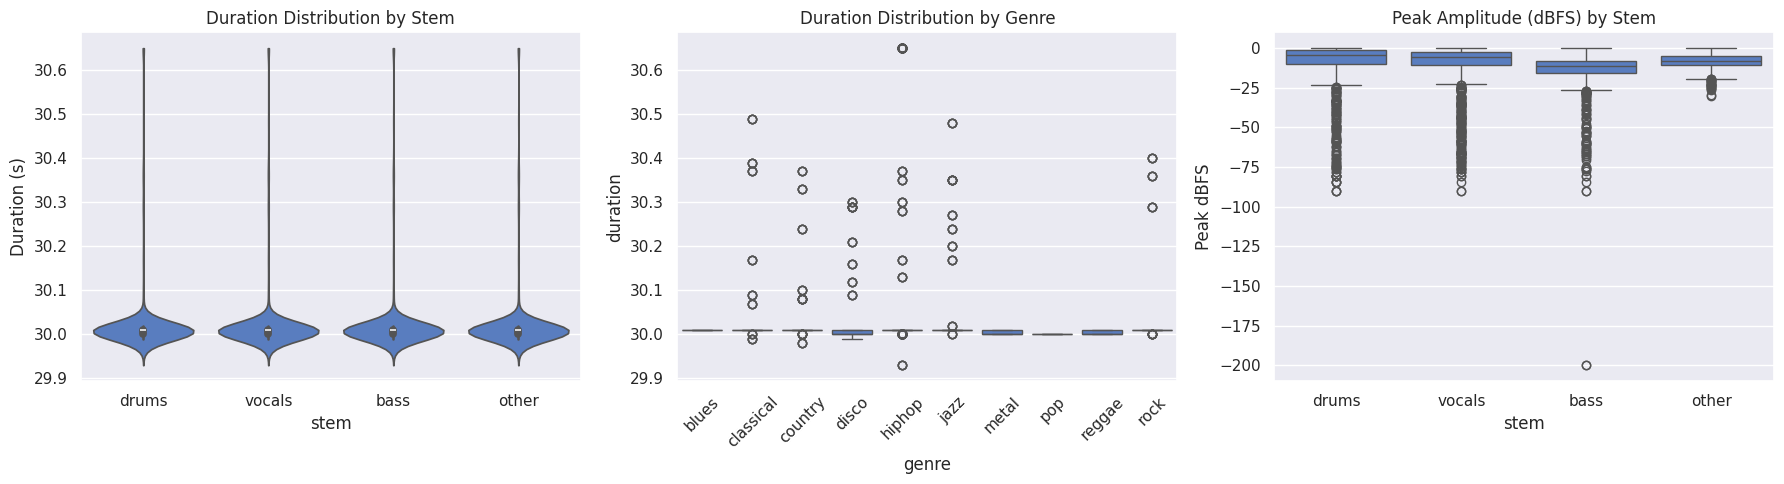

In [6]:
def profile_audio(file_paths, sample_limit=None):
    paths = file_paths if sample_limit is None else file_paths[:sample_limit]
    records = []

    for row in tqdm(paths.itertuples(), total=len(paths)):
        try:
            y, sr = librosa.load(row.path, sr=None, mono=True)
            duration  = len(y) / sr
            peak_db   = 20 * np.log10(np.max(np.abs(y)) + 1e-10)
            rms_db    = 20 * np.log10(np.sqrt(np.mean(y**2)) + 1e-10)

            records.append({
                "genre":    row.genre,
                "stem":     row.stem,
                "sr":       sr,
                "duration": round(duration, 2),
                "peak_db":  round(peak_db, 2),
                "rms_db":   round(rms_db, 2),
            })
        except Exception:
            continue

    return pd.DataFrame(records)


valid_paths  = inventory[inventory["exists"] & (inventory["size_kb"] > 4)]
audio_stats  = profile_audio(valid_paths)

print("\n=== UNIQUE SAMPLE RATES ===")
print(audio_stats["sr"].unique())

print("\n=== DURATION STATS (seconds) ===")
print(audio_stats.groupby("stem")["duration"].describe().round(2))

print("\n=== PEAK dB STATS ===")
print(audio_stats.groupby("stem")["peak_db"].describe().round(2))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=audio_stats, x="stem", y="duration", ax=axes[0], cut=0)
axes[0].set_title("Duration Distribution by Stem")
axes[0].set_ylabel("Duration (s)")

sns.boxplot(data=audio_stats, x="genre", y="duration", ax=axes[1])
axes[1].set_title("Duration Distribution by Genre")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=audio_stats, x="stem", y="peak_db", ax=axes[2])
axes[2].set_title("Peak Amplitude (dBFS) by Stem")
axes[2].set_ylabel("Peak dBFS")

plt.tight_layout()
plt.savefig("audio_properties.png", dpi=150)
plt.show()

100%|██████████| 4000/4000 [03:10<00:00, 21.02it/s]



=== SILENCE ANALYSIS ===
Files with silence >= 5s : 814

Flagged by stem:
stem
bass      218
drums     167
other      55
vocals    374
dtype: int64

Flagged by genre:
genre
blues        109
classical    242
country       55
disco         34
hiphop        60
jazz         142
metal         58
pop           24
reggae        37
rock          53
dtype: int64

Silence location breakdown:
location
middle    379
start     277
end       158
Name: count, dtype: int64


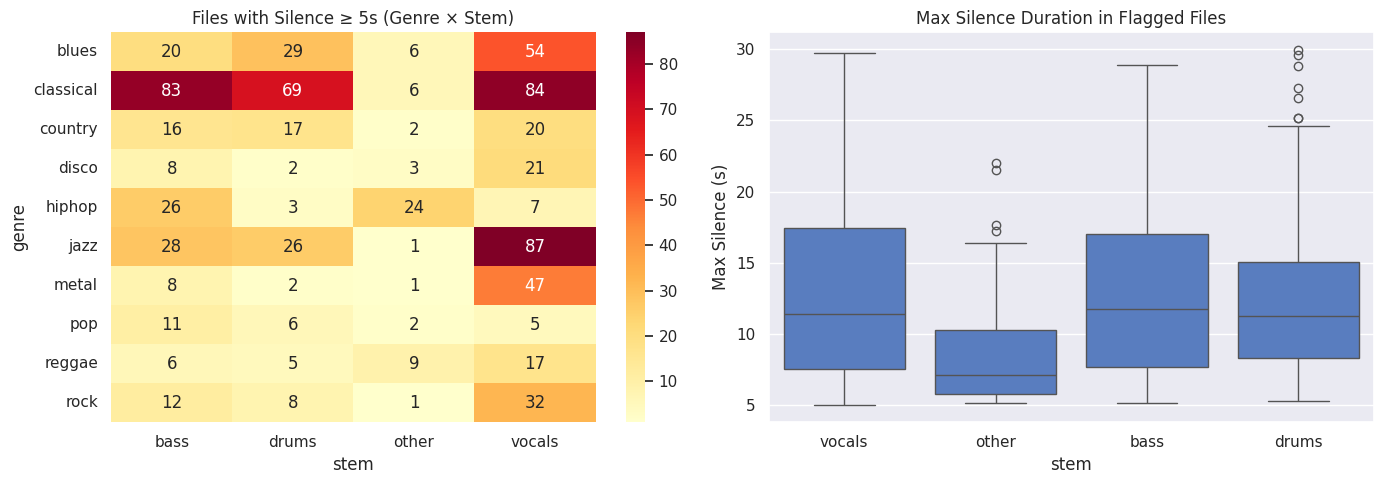

In [7]:
def analyse_silence(valid_paths, top_db=20, threshold_sec=5.0):
    records = []

    for row in tqdm(valid_paths.itertuples(), total=len(valid_paths)):
        try:
            y, sr = librosa.load(row.path, sr=SR, mono=True)
            total_dur  = len(y) / sr
            intervals  = librosa.effects.split(y, top_db=top_db)

            if len(intervals) == 0:
                max_silence = total_dur
                location    = "full"
            else:
                gaps = []
                if intervals[0][0] > 0:
                    gaps.append(("start", intervals[0][0] / sr))
                if intervals[-1][1] < len(y):
                    gaps.append(("end", (len(y) - intervals[-1][1]) / sr))
                for i in range(len(intervals) - 1):
                    gap = (intervals[i+1][0] - intervals[i][1]) / sr
                    if gap > 0:
                        gaps.append(("middle", gap))

                if not gaps:
                    max_silence = 0
                    location    = "none"
                else:
                    location_type, max_silence = max(gaps, key=lambda x: x[1])
                    location = location_type

            records.append({
                "genre":       row.genre,
                "stem":        row.stem,
                "duration":    round(total_dur, 2),
                "max_silence": round(max_silence, 2),
                "location":    location,
                "flagged":     max_silence >= threshold_sec,
            })
        except Exception:
            continue

    return pd.DataFrame(records)


silence_df = analyse_silence(valid_paths)

print("\n=== SILENCE ANALYSIS ===")
print(f"Files with silence >= 5s : {silence_df['flagged'].sum()}")
print(f"\nFlagged by stem:\n{silence_df[silence_df['flagged']].groupby('stem').size()}")
print(f"\nFlagged by genre:\n{silence_df[silence_df['flagged']].groupby('genre').size()}")
print(f"\nSilence location breakdown:\n{silence_df[silence_df['flagged']]['location'].value_counts()}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flagged_pivot = (
    silence_df[silence_df["flagged"]]
    .groupby(["genre", "stem"])
    .size()
    .unstack(fill_value=0)
)
sns.heatmap(flagged_pivot, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Files with Silence ≥ 5s (Genre × Stem)")

sns.boxplot(data=silence_df[silence_df["flagged"]], x="stem", y="max_silence", ax=axes[1])
axes[1].set_title("Max Silence Duration in Flagged Files")
axes[1].set_ylabel("Max Silence (s)")

plt.tight_layout()
plt.savefig("silence_analysis.png", dpi=150)
plt.show()

In [8]:
def extract_spectral_features(file_paths, n_sample=20):
    records = []

    for genre in GENRES:
        genre_rows = file_paths[
            (file_paths["genre"] == genre) &
            (file_paths["stem"].isin(["drums", "vocals", "bass"]))
        ].head(n_sample)

        for row in genre_rows.itertuples():
            try:
                y, sr = librosa.load(row.path, sr=SR, duration=30, mono=True)

                if len(y) == 0:
                    continue

                # --- Features ---
                centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
                rolloff  = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
                zcr      = np.mean(librosa.feature.zero_crossing_rate(y))
                rms      = np.mean(librosa.feature.rms(y=y))

                # FIX: tempo sometimes comes as ndarray
                tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
                tempo = float(np.atleast_1d(tempo)[0])

                records.append({
                    "genre": genre,
                    "spectral_centroid": float(centroid),
                    "spectral_rolloff":  float(rolloff),
                    "zcr":               float(zcr),
                    "tempo":             tempo,
                    "rms":               float(rms),
                })

            except Exception:
                continue

    df = pd.DataFrame(records)

    # --- CLEANING STEP (CRITICAL) ---
    df = df.dropna()

    # Remove any rows with weird types (safety)
    df = df[df.applymap(lambda x: np.isscalar(x)).all(axis=1)]

    return df

/tmp/ipykernel_55/2940549462.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df[df.applymap(lambda x: np.isscalar(x)).all(axis=1)]



=== SPECTRAL CENTROID BY GENRE ===
genre
country      2987.2
disco        2895.5
metal        2650.7
pop          2630.1
hiphop       2339.9
reggae       2330.3
blues        2274.6
jazz         1931.4
rock         1914.3
classical     850.9
Name: spectral_centroid, dtype: float64


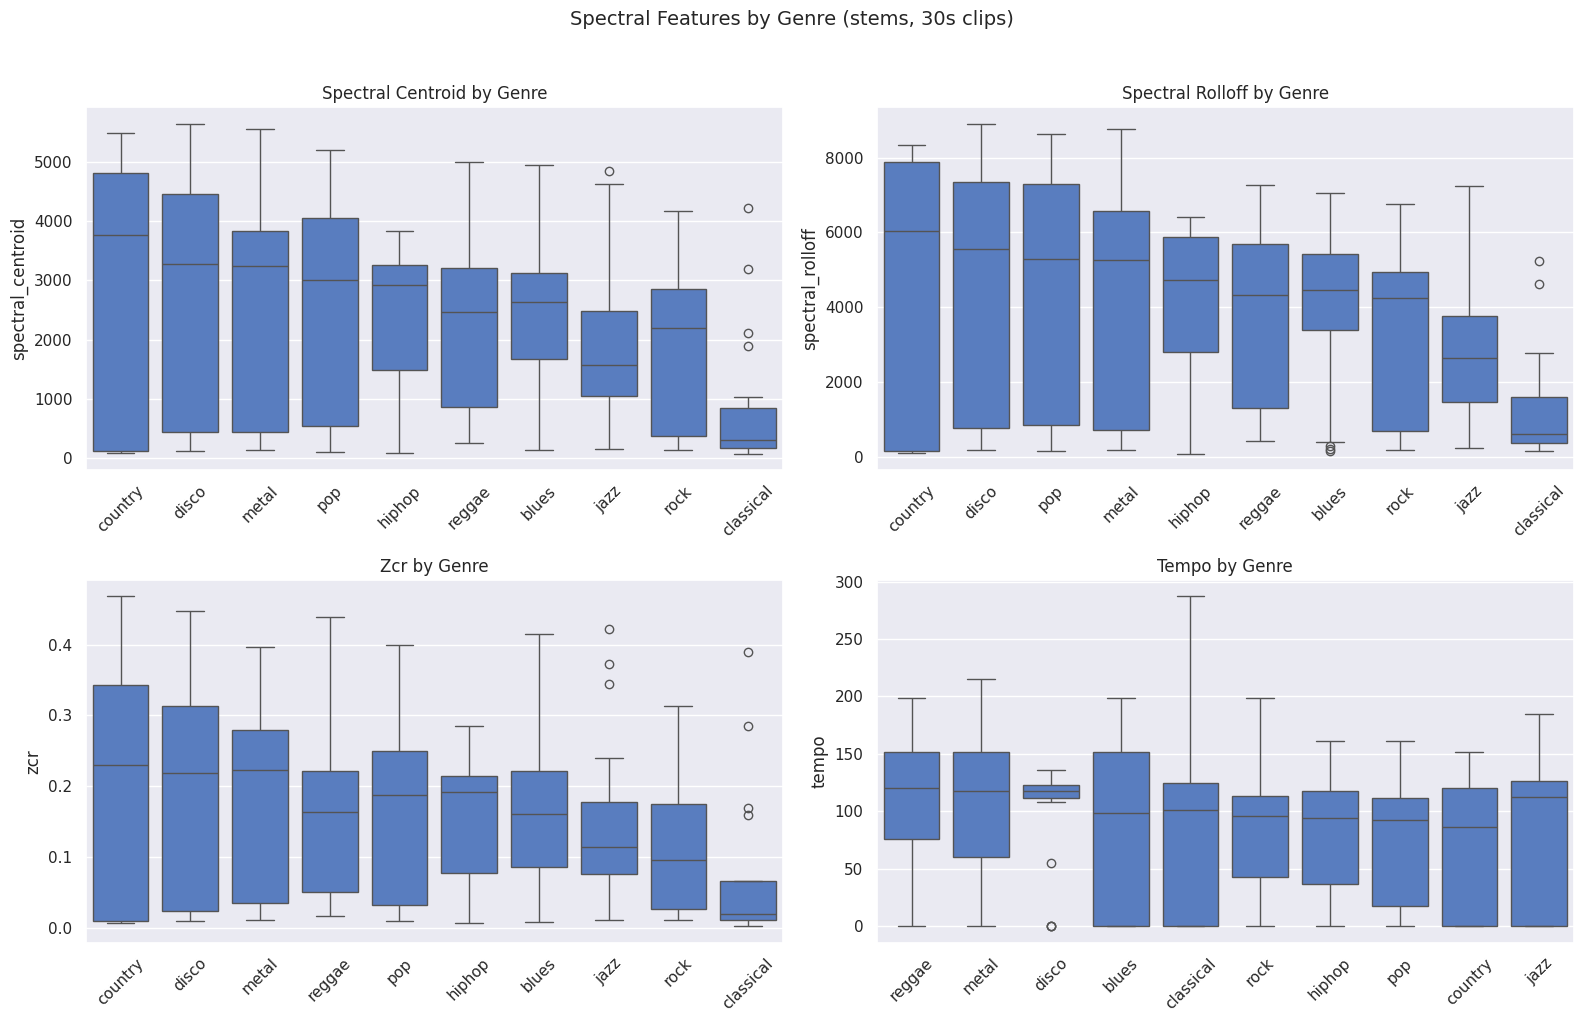

In [9]:
spectral_df = extract_spectral_features(valid_paths)

print("\n=== SPECTRAL CENTROID BY GENRE ===")
print(
    spectral_df.groupby("genre")["spectral_centroid"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

features_to_plot = ["spectral_centroid", "spectral_rolloff", "zcr", "tempo"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, feat in zip(axes.flatten(), features_to_plot):
    order = (
        spectral_df.groupby("genre")[feat]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()   # ✅ ensure clean list
    )

    sns.boxplot(
        data=spectral_df,
        x="genre",
        y=feat,
        order=order,
        ax=ax
    )

    ax.set_title(f"{feat.replace('_', ' ').title()} by Genre")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")

plt.suptitle("Spectral Features by Genre (stems, 30s clips)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("spectral_features.png", dpi=150)
plt.show()


=== ESC-50 OVERVIEW ===
Total clips   : 2000
Total classes : 50
Total folds   : 5

Clips per category (first 10):
category
dog                40
chirping_birds     40
vacuum_cleaner     40
thunderstorm       40
door_wood_knock    40
can_opening        40
crow               40
clapping           40
fireworks          40
chainsaw           40
Name: count, dtype: int64


100%|██████████| 200/200 [00:02<00:00, 71.98it/s]



=== ESC-50 AUDIO STATS ===
       duration  peak_db  rms_db
count     200.0   200.00  200.00
mean        5.0    -4.32  -24.48
std         0.0     5.92    9.35
min         5.0   -25.27  -49.29
25%         5.0    -5.76  -30.89
50%         5.0    -1.63  -21.68
75%         5.0     0.00  -17.26
max         5.0     0.00   -7.48


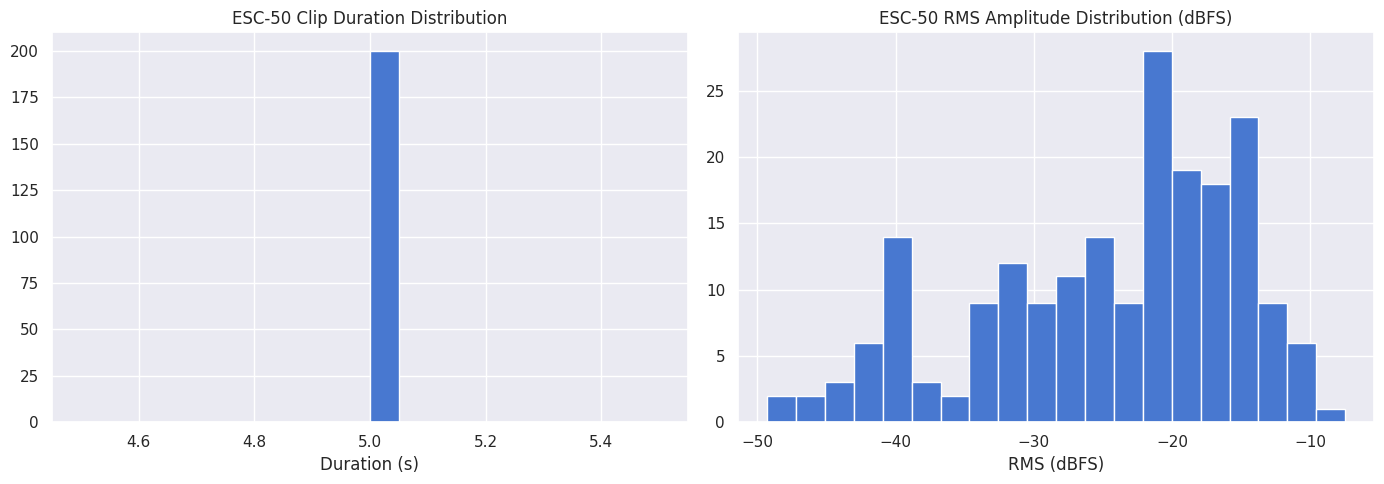

In [10]:
esc50_meta = pd.read_csv(os.path.join(ESC50_PATH, "meta", "esc50.csv"))

print("\n=== ESC-50 OVERVIEW ===")
print(f"Total clips   : {len(esc50_meta)}")
print(f"Total classes : {esc50_meta['category'].nunique()}")
print(f"Total folds   : {esc50_meta['fold'].nunique()}")
print(f"\nClips per category (first 10):\n{esc50_meta['category'].value_counts().head(10)}")


def profile_esc50_audio(meta, audio_dir, n=200):
    records = []
    for row in tqdm(meta.head(n).itertuples(), total=n):
        fpath = os.path.join(audio_dir, row.filename)
        try:
            y, sr = librosa.load(fpath, sr=None, mono=True)
            records.append({
                "category": row.category,
                "duration": round(len(y) / sr, 2),
                "peak_db":  round(20 * np.log10(np.max(np.abs(y)) + 1e-10), 2),
                "rms_db":   round(20 * np.log10(np.sqrt(np.mean(y**2)) + 1e-10), 2),
            })
        except Exception:
            continue
    return pd.DataFrame(records)


esc_audio_path = os.path.join(ESC50_PATH, "audio")
esc50_stats    = profile_esc50_audio(esc50_meta, esc_audio_path)

print("\n=== ESC-50 AUDIO STATS ===")
print(esc50_stats[["duration", "peak_db", "rms_db"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

esc50_stats["duration"].hist(bins=20, ax=axes[0], edgecolor="white")
axes[0].set_title("ESC-50 Clip Duration Distribution")
axes[0].set_xlabel("Duration (s)")

esc50_stats["rms_db"].hist(bins=20, ax=axes[1], edgecolor="white")
axes[1].set_title("ESC-50 RMS Amplitude Distribution (dBFS)")
axes[1].set_xlabel("RMS (dBFS)")

plt.tight_layout()
plt.savefig("esc50_exploration.png", dpi=150)
plt.show()


=== TEST SET OVERVIEW ===
Total mashups : 3020
   id              filename
0   1  mashups/song0001.wav
1   2  mashups/song0002.wav
2   3  mashups/song0003.wav
3   4  mashups/song0004.wav
4   5  mashups/song0005.wav


100%|██████████| 30/30 [00:02<00:00, 11.50it/s]



=== MASHUP AUDIO STATS (sample of 30) ===
       duration  peak_db  rms_db    zcr  centroid       sr
count     30.00    30.00   30.00  30.00     30.00     30.0
mean      29.54    -0.00  -17.22   0.11   2464.21  22050.0
std        1.51     0.01    1.20   0.03    564.44      0.0
min       22.34    -0.02  -19.83   0.05   1658.80  22050.0
25%       29.89     0.00  -17.89   0.09   2033.05  22050.0
50%       30.00     0.00  -16.95   0.11   2436.25  22050.0
75%       30.01     0.00  -16.62   0.14   2945.62  22050.0
max       30.30    -0.00  -14.65   0.20   3812.30  22050.0


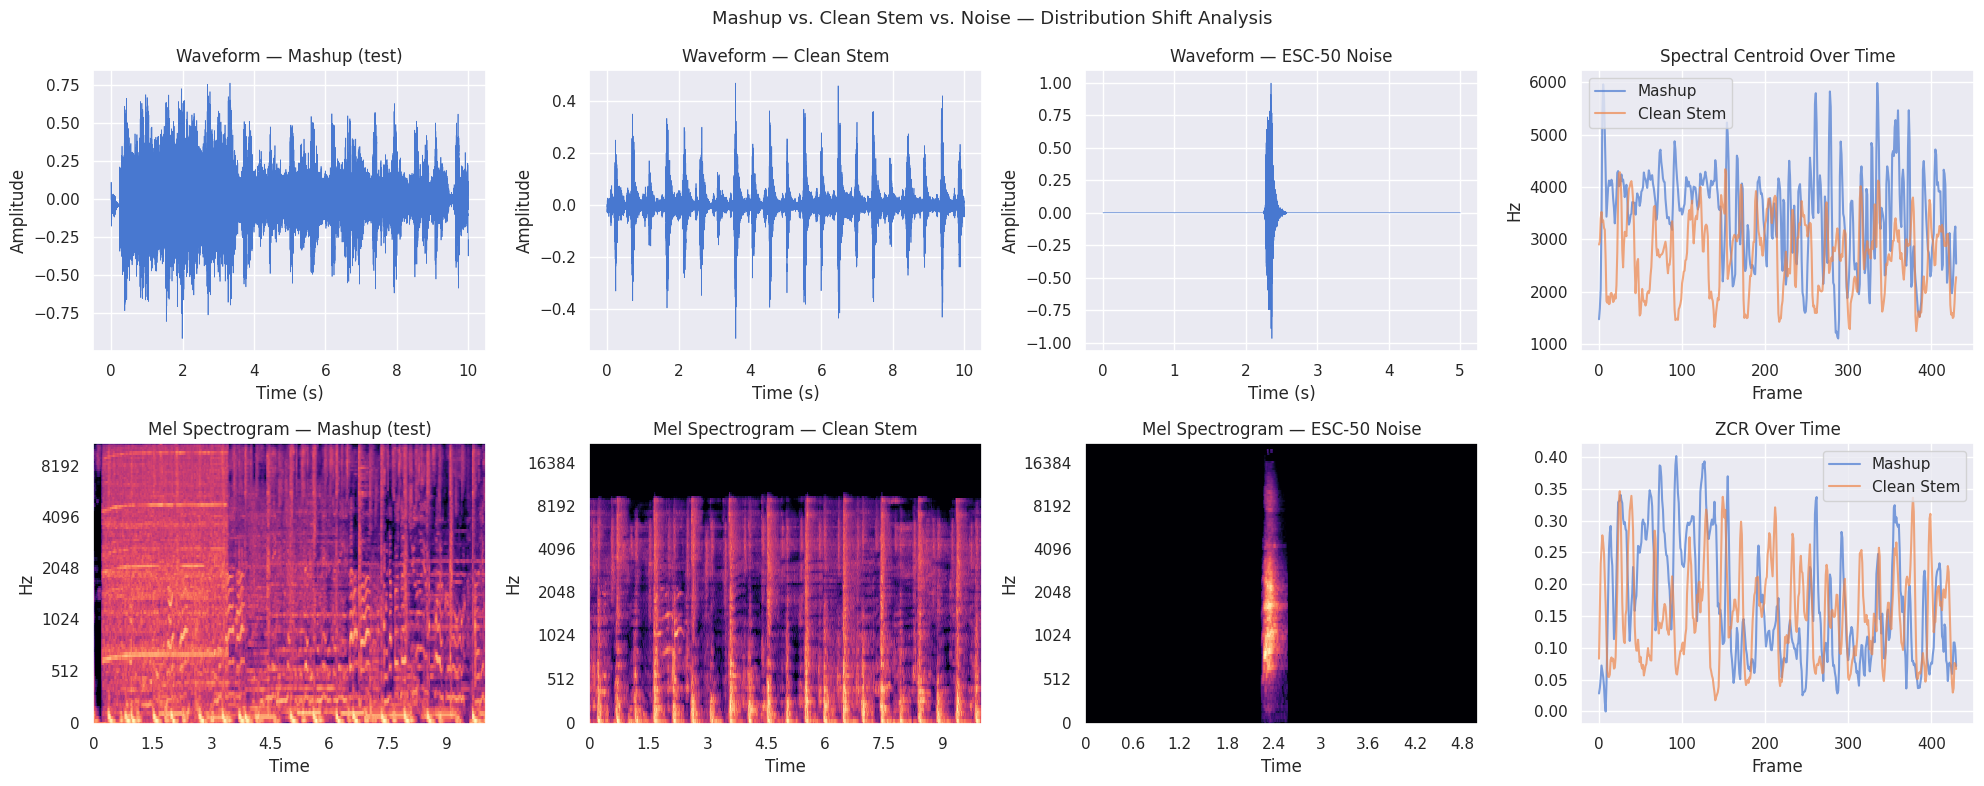

In [11]:
test_df = pd.read_csv(TEST_CSV)
print(f"\n=== TEST SET OVERVIEW ===")
print(f"Total mashups : {len(test_df)}")
print(test_df.head())

mashup_files = sorted(Path(MASHUP_PATH).glob("*.wav"))[:30]


def profile_mashups(files):
    records = []
    for f in tqdm(files):
        try:
            y, sr = librosa.load(str(f), sr=None, mono=True)  # native SR
            records.append({
                "file":     f.name,
                "duration": round(len(y) / sr, 2),
                "peak_db":  round(20 * np.log10(np.max(np.abs(y)) + 1e-10), 2),
                "rms_db":   round(20 * np.log10(np.sqrt(np.mean(y**2)) + 1e-10), 2),
                "zcr":      round(np.mean(librosa.feature.zero_crossing_rate(y)), 5),
                "centroid": round(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)), 1),
                "sr":       sr,
            })
        except Exception:
            continue
    return pd.DataFrame(records)


mashup_stats = profile_mashups(mashup_files)

print("\n=== MASHUP AUDIO STATS (sample of 30) ===")
print(mashup_stats[["duration", "peak_db", "rms_db", "zcr", "centroid", "sr"]].describe().round(2))


def plot_waveform_and_spectrogram(fpath, title, ax_wave, ax_spec, duration=10):
    y, sr = librosa.load(fpath, sr=None, duration=duration, mono=True)
    times = np.linspace(0, len(y) / sr, len(y))

    ax_wave.plot(times, y, linewidth=0.5)
    ax_wave.set_title(f"Waveform — {title}")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")

    S    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax_spec)
    ax_spec.set_title(f"Mel Spectrogram — {title}")


fig, axes = plt.subplots(2, 4, figsize=(20, 8))

sample_mashup = str(mashup_files[0])
sample_stem   = valid_paths.iloc[0]["path"]   # any stem is fine
sample_noise  = os.path.join(esc_audio_path, esc50_meta.iloc[0]["filename"])

plot_waveform_and_spectrogram(sample_mashup, "Mashup (test)",  axes[0][0], axes[1][0])
plot_waveform_and_spectrogram(sample_stem,   "Clean Stem",     axes[0][1], axes[1][1])
plot_waveform_and_spectrogram(sample_noise,  "ESC-50 Noise",   axes[0][2], axes[1][2])

y_mashup, sr_m = librosa.load(sample_mashup, sr=SR, duration=10, mono=True)
y_stem,   sr_s = librosa.load(sample_stem,   sr=SR, duration=10, mono=True)

centroid_comparison = pd.DataFrame({
    "Mashup":     librosa.feature.spectral_centroid(y=y_mashup, sr=sr_m)[0],
    "Clean Stem": librosa.feature.spectral_centroid(y=y_stem,   sr=sr_s)[0],
})
centroid_comparison.plot(ax=axes[0][3], alpha=0.7)
axes[0][3].set_title("Spectral Centroid Over Time")
axes[0][3].set_xlabel("Frame")
axes[0][3].set_ylabel("Hz")

zcr_comparison = pd.DataFrame({
    "Mashup":     librosa.feature.zero_crossing_rate(y_mashup)[0],
    "Clean Stem": librosa.feature.zero_crossing_rate(y_stem)[0],
})
zcr_comparison.plot(ax=axes[1][3], alpha=0.7)
axes[1][3].set_title("ZCR Over Time")
axes[1][3].set_xlabel("Frame")

plt.suptitle("Mashup vs. Clean Stem vs. Noise — Distribution Shift Analysis", fontsize=13)
plt.tight_layout()
plt.savefig("distribution_shift.png", dpi=150)
plt.show()

In [12]:
print("\n" + "="*55)
print("EDA SUMMARY")
print("="*55)
print(f"Training files (stems)     : {inventory['exists'].sum()}")
print(f"Missing stems              : {(~inventory['exists']).sum()}")
print(f"Corrupted (size 0)         : {(inventory['size_kb'] == 0).sum()}")
print(f"Files with ≥ 5s silence    : {silence_df['flagged'].sum()}")
print(f"Unique sample rates found  : {audio_stats['sr'].nunique()}")
print(f"Mean duration (all stems)  : {audio_stats['duration'].mean():.1f}s")
print(f"ESC-50 noise classes       : {esc50_meta['category'].nunique()}")
print(f"Total mashup test files    : {len(test_df)}")
print("="*55)


EDA SUMMARY
Training files (stems)     : 4000
Missing stems              : 0
Corrupted (size 0)         : 0
Files with ≥ 5s silence    : 814
Unique sample rates found  : 1
Mean duration (all stems)  : 30.0s
ESC-50 noise classes       : 50
Total mashup test files    : 3020


## Data Augmentation Pipeline

In [5]:
import os
sample_genre = GENRES[0]
sample_song  = os.listdir(os.path.join(STEMS_PATH, sample_genre))[0]
print(os.listdir(os.path.join(STEMS_PATH, sample_genre, sample_song)))

['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']


In [6]:
import random

SR          = 22050
TARGET_SEC  = 30
TARGET_LEN  = SR * TARGET_SEC
N_MELS      = 128
N_MFCC      = 20
N_FFT       = 2048
HOP_LEN     = 512
N_SAMPLES_PER_GENRE = 500
T_FRAMES   = (TARGET_LEN // HOP_LEN) + 1

STEMS = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]   # was others.wav

random.seed(42)
np.random.seed(42)


def build_stem_index():
    records = []
    for genre in GENRES:
        genre_path = os.path.join(STEMS_PATH, genre)
        for song in sorted(os.listdir(genre_path)):
            song_path = os.path.join(genre_path, song)
            if not os.path.isdir(song_path):
                continue
            for stem_file in STEMS:
                fpath = os.path.join(song_path, stem_file)
                if os.path.exists(fpath) and os.path.getsize(fpath) > 4096:
                    records.append({
                        "genre": genre,
                        "stem":  stem_file.replace(".wav", ""),
                        "path":  fpath
                    })
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No stem files found — check dataset path")
    return df


def build_noise_pool():
    esc50_meta = pd.read_csv(os.path.join(ESC50_PATH, "meta", "esc50.csv"))
    audio_dir  = os.path.join(ESC50_PATH, "audio")
    return [os.path.join(audio_dir, f) for f in esc50_meta["filename"]]


stem_df    = build_stem_index()
noise_pool = build_noise_pool()

print("=== STEM INDEX ===")
print(stem_df.groupby(["genre", "stem"]).size().unstack(fill_value=0))
print(f"\nNoise clips available: {len(noise_pool)}")

=== STEM INDEX ===
stem       bass  drums  other  vocals
genre                                
blues       100    100    100     100
classical   100    100    100     100
country     100    100    100     100
disco       100    100    100     100
hiphop      100    100    100     100
jazz        100    100    100     100
metal       100    100    100     100
pop         100    100    100     100
reggae      100    100    100     100
rock        100    100    100     100

Noise clips available: 2000


In [15]:
# Audio Utilities

def rms_normalize(y, target_db=-17):
    rms        = np.sqrt(np.mean(y ** 2) + 1e-8)
    target_rms = 10 ** (target_db / 20)
    return y * (target_rms / (rms + 1e-8))


def smart_crop(y, target_len=TARGET_LEN):
    if len(y) >= target_len:
        start = random.randint(0, len(y) - target_len)
        return y[start : start + target_len]
    return np.pad(y, (0, target_len - len(y)))


def random_gain(y, low=0.6, high=1.4):
    return y * np.random.uniform(low, high)


def add_esc50_noise(y, noise_pool, snr_range=(0, 15)):
    noise, _ = librosa.load(random.choice(noise_pool), sr=SR, mono=True)

    snr_db            = np.random.uniform(*snr_range)
    signal_rms        = np.sqrt(np.mean(y ** 2) + 1e-8)
    noise_rms         = np.sqrt(np.mean(noise ** 2) + 1e-8)
    desired_noise_rms = signal_rms / (10 ** (snr_db / 20))
    noise             = noise * (desired_noise_rms / noise_rms)

    if random.random() < 0.5 and len(noise) < len(y):
        # true partial overlay — only valid when noise is shorter than signal
        start = random.randint(0, len(y) - len(noise))
        y = y.copy()
        y[start : start + len(noise)] += noise
    else:
        if len(noise) < len(y):
            noise = np.tile(noise, int(np.ceil(len(y) / len(noise))))
        y = y + noise[: len(y)]

    return y

In [7]:
def load_stem_cache(stem_df):
    cache = {}   # (genre, stem) → list of np.ndarray

    all_rows = list(stem_df.itertuples())

    for row in tqdm(all_rows, desc="Loading stems into RAM"):
        try:
            y, _ = librosa.load(row.path, sr=SR, mono=True)
            key  = (row.genre, row.stem)   # stem already without .wav
            cache.setdefault(key, []).append(y)
        except Exception:
            continue

    print(f"\nCached {sum(len(v) for v in cache.values())} stems "
          f"across {len(cache)} (genre, stem) buckets")

    return cache


print("Pre-loading stems...")
stem_cache = load_stem_cache(stem_df)

print("\nPre-loading noise clips...")

noise_cache = []

for path in tqdm(noise_pool, desc="Loading noise"):
    try:
        y, _ = librosa.load(path, sr=SR, mono=True)
        noise_cache.append(y)
    except Exception:
        continue

print(f"Cached {len(noise_cache)} noise clips")

Pre-loading stems...


Loading stems into RAM: 100%|██████████| 4000/4000 [07:30<00:00,  8.88it/s]



Cached 4000 stems across 40 (genre, stem) buckets

Pre-loading noise clips...


Loading noise: 100%|██████████| 2000/2000 [00:28<00:00, 70.51it/s]

Cached 2000 noise clips


In [8]:
import torch

def precompute_tempos(stem_cache):
    tempo_cache = {}
    for (genre, stem), audio_list in tqdm(stem_cache.items(), desc="Computing tempos"):
        tempos = []
        for y in audio_list:
            try:
                t = float(np.atleast_1d(librosa.beat.beat_track(y=y, sr=SR)[0])[0])
                tempos.append(t if t > 0 else 120.0)
            except Exception:
                tempos.append(120.0)
        tempo_cache[(genre, stem)] = tempos
    return tempo_cache

tempo_cache = precompute_tempos(stem_cache)
torch.save(tempo_cache, "/kaggle/working/tempo_cache.pt")

Computing tempos: 100%|██████████| 40/40 [04:38<00:00,  6.95s/it]


In [9]:
def mix_stems_cached(stem_cache, tempo_cache, genre):
    mixed  = np.zeros(TARGET_LEN, dtype=np.float32)
    stems  = ["drums", "vocals", "bass", "other"]

    loaded = {}
    for stem in stems:
        pool = stem_cache.get((genre, stem), [])
        if not pool:
            continue
        idx           = random.randrange(len(pool))
        loaded[stem]  = (pool[idx].copy(), idx)

    if not loaded:
        return mixed

    # anchor tempo from drums, fallback to first available stem
    anchor_stem = "drums" if "drums" in loaded else next(iter(loaded))
    anchor_idx  = loaded[anchor_stem][1]
    target_tempo = tempo_cache.get((genre, anchor_stem), [120.0])
    target_tempo = target_tempo[anchor_idx] if anchor_idx < len(target_tempo) else 120.0

    for stem, (y, idx) in loaded.items():
        if stem != anchor_stem and target_tempo > 0:
            stem_tempos  = tempo_cache.get((genre, stem), [120.0])
            stem_tempo   = stem_tempos[idx] if idx < len(stem_tempos) else 120.0
            if stem_tempo > 0:
                rate = target_tempo / stem_tempo
                rate = np.clip(rate, 0.8, 1.25)
                if abs(rate - 1.0) > 0.02:
                    y = librosa.effects.time_stretch(y, rate=rate)

        y      = smart_crop(y)
        y      = rms_normalize(y)
        mixed += np.random.uniform(0.5, 1.5) * y

    return mixed



def add_noise_cached(y, noise_cache, snr_range=(0, 15)):
    noise = random.choice(noise_cache).copy()

    snr_db            = np.random.uniform(*snr_range)
    signal_rms        = np.sqrt(np.mean(y ** 2) + 1e-8)
    noise_rms         = np.sqrt(np.mean(noise ** 2) + 1e-8)
    desired_noise_rms = signal_rms / (10 ** (snr_db / 20))
    noise             = noise * (desired_noise_rms / noise_rms)

    if random.random() < 0.5 and len(noise) < len(y):
        start = random.randint(0, len(y) - len(noise))
        y = y.copy()
        y[start : start + len(noise)] += noise
    else:
        if len(noise) < len(y):
            noise = np.tile(noise, int(np.ceil(len(y) / len(noise))))
        y = y + noise[: len(y)]

    return y


def augment_pipeline_cached(stem_cache, noise_cache, genre, tempo_cache=None):
    y = mix_stems_cached(stem_cache, tempo_cache, genre) if tempo_cache else mix_stems_cached_notempo(stem_cache, genre)
    y = rms_normalize(y)
    y = random_gain(y, low=0.7, high=1.3)
    y = add_noise_cached(y, noise_cache)
    y = y / (np.max(np.abs(y)) + 1e-8)
    y = y[:TARGET_LEN] if len(y) >= TARGET_LEN else np.pad(y, (0, TARGET_LEN - len(y)))
    return y.astype(np.float32)

## Feature extraction pipeline

In [10]:
import wandb
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [20]:
def extract_tabular_features_fast(y, sr=SR):
    mfcc     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                     n_fft=N_FFT, hop_length=HOP_LEN)
    chroma   = librosa.feature.chroma_stft(y=y, sr=sr,
                                            n_fft=N_FFT, hop_length=HOP_LEN)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr,
                                                  n_fft=N_FFT, hop_length=HOP_LEN)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LEN)
    rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LEN)
    zcr      = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LEN)
    rms      = librosa.feature.rms(y=y, hop_length=HOP_LEN)

    return np.concatenate([
        mfcc.mean(axis=1),     mfcc.std(axis=1),       # 40
        chroma.mean(axis=1),   chroma.std(axis=1),      # 24
        contrast.mean(axis=1), contrast.std(axis=1),    # 14
        centroid.mean(axis=1), centroid.std(axis=1),    # 2
        rolloff.mean(axis=1),  rolloff.std(axis=1),     # 2
        zcr.mean(axis=1),      zcr.std(axis=1),         # 2
        rms.mean(axis=1),      rms.std(axis=1),         # 2
    ]).astype(np.float32)   # total: 86 features

In [21]:
FEAT_NAMES = (
    [f"mfcc_mean_{i}"     for i in range(N_MFCC)] +
    [f"mfcc_std_{i}"      for i in range(N_MFCC)] +
    [f"chroma_mean_{i}"   for i in range(12)]      +
    [f"chroma_std_{i}"    for i in range(12)]      +
    [f"contrast_mean_{i}" for i in range(7)]       +
    [f"contrast_std_{i}"  for i in range(7)]       +
    ["centroid_mean", "centroid_std",
     "rolloff_mean",  "rolloff_std",
     "zcr_mean",      "zcr_std",
     "rms_mean",      "rms_std"]
)   # 86 features

In [23]:
def build_dataset(stem_cache, noise_cache, tempo_cache, n_per_genre=N_SAMPLES_PER_GENRE):
    X, y = [], []

    for genre in GENRES:
        print(f"  {genre}...", end=" ", flush=True)
        ok = 0

        for seed in range(n_per_genre * 2):
            if ok >= n_per_genre:
                break
            random.seed(seed)
            np.random.seed(seed)
            try:
                audio = augment_pipeline_cached(stem_cache, noise_cache, genre, tempo_cache)
                feats = extract_tabular_features_fast(audio)
                if np.isnan(feats).any() or np.isinf(feats).any():
                    continue
                X.append(feats)
                y.append(genre)
                ok += 1
            except Exception as e:
                print(f"\n    error: {e}")
                continue

        print(f"{ok}/{n_per_genre}")

    return np.array(X, dtype=np.float32), np.array(y)


print("\nBuilding augmented dataset...")
X, y = build_dataset(stem_cache, noise_cache, tempo_cache, n_per_genre=150)
print(f"\nDataset shape : {X.shape}")
print(f"Label counts  :\n{pd.Series(y).value_counts()}")


Building augmented dataset...
  blues... 150/150
  classical... 150/150
  country... 150/150
  disco... 150/150
  hiphop... 150/150
  jazz... 150/150
  metal... 150/150
  pop... 150/150
  reggae... 150/150
  rock... 150/150

Dataset shape : (1500, 86)
Label counts  :
blues        150
classical    150
country      150
disco        150
hiphop       150
jazz         150
metal        150
pop          150
reggae       150
rock         150
Name: count, dtype: int64


## Baseline model

In [24]:
# Train Validation Split
le     = LabelEncoder().fit(GENRES)
y_enc  = le.transform(y)
scaler = StandardScaler()

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
print(f"\nTrain : {X_train_sc.shape}  |  Val : {X_val_sc.shape}")


Train : (1200, 86)  |  Val : (300, 86)


In [25]:
run = wandb.init(
    project = "DL-GenAI-Project-2026",
    name    = "classical_ml_baseline",
    config  = {
        "n_samples_per_genre": N_SAMPLES_PER_GENRE,
        "n_features":          X.shape[1],
        "val_split":           0.2,
        "rf_estimators":       300,
        "xgb_estimators":      500,
    },
    reinit  = True,
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [26]:
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 20,
    min_samples_leaf = 2,
    n_jobs          = -1,
    random_state    = 42,
)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_val_sc)
rf_f1   = f1_score(y_val, rf_pred, average="macro")
print(f"Random Forest Macro F1: {rf_f1:.4f}")
wandb.log({"rf/val_macro_f1": rf_f1})


Training Random Forest...
Random Forest Macro F1: 0.5797


In [27]:
print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators        = 500,
    max_depth           = 6,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 3,
    gamma               = 0.1,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    tree_method         = "hist",
    num_class           = len(GENRES),
    eval_metric         = "mlogloss",
    early_stopping_rounds = 30,
    random_state        = 42,
    verbosity           = 0,
)
xgb.fit(X_train_sc, y_train,
        eval_set=[(X_val_sc, y_val)], verbose=False)
xgb_pred = xgb.predict(X_val_sc)
xgb_f1   = f1_score(y_val, xgb_pred, average="macro")
print(f"XGBoost Macro F1: {xgb_f1:.4f}")
wandb.log({"xgb/val_macro_f1": xgb_f1})


Training XGBoost...
XGBoost Macro F1: 0.6509



=== BEST MODEL: XGBoost ===
              precision    recall  f1-score   support

       blues       0.56      0.60      0.58        30
   classical       0.90      0.90      0.90        30
     country       0.57      0.53      0.55        30
       disco       0.53      0.53      0.53        30
      hiphop       0.57      0.53      0.55        30
        jazz       0.75      0.60      0.67        30
       metal       0.93      0.90      0.92        30
         pop       0.76      0.87      0.81        30
      reggae       0.55      0.53      0.54        30
        rock       0.42      0.50      0.45        30

    accuracy                           0.65       300
   macro avg       0.66      0.65      0.65       300
weighted avg       0.66      0.65      0.65       300



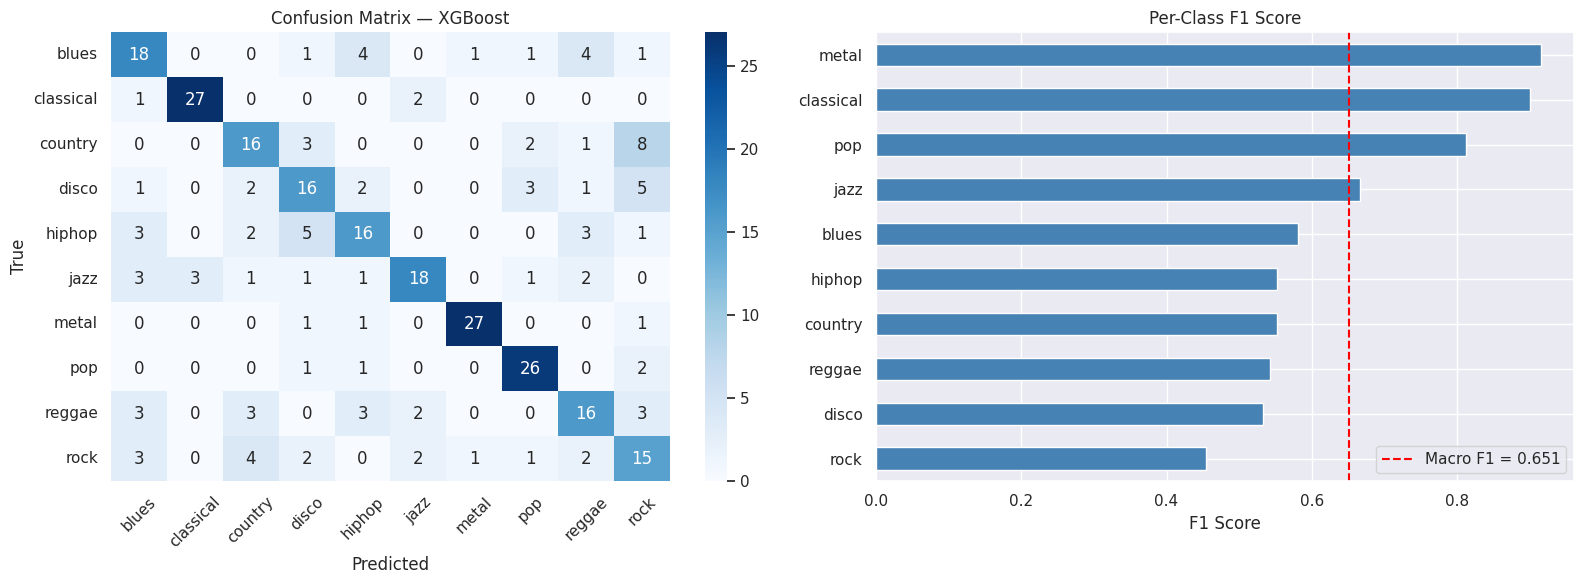

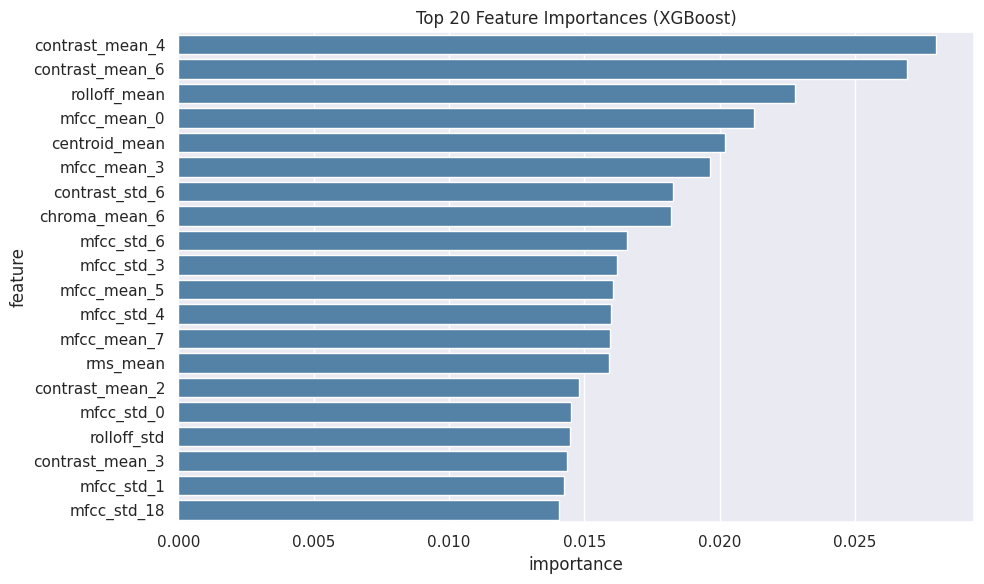

In [29]:
best_pred  = xgb_pred if xgb_f1 >= rf_f1 else rf_pred
best_label = "XGBoost" if xgb_f1 >= rf_f1 else "Random Forest"
best_f1    = max(xgb_f1, rf_f1)

print(f"\n=== BEST MODEL: {best_label} ===")
print(classification_report(y_val, best_pred, target_names=le.classes_))

wandb.log({"best_model": best_label, "best_val_macro_f1": best_f1})

# per-class F1 table
per_class_f1 = f1_score(y_val, best_pred, average=None)
wandb.log({
    "per_class_f1": wandb.Table(
        columns = ["genre", "f1"],
        data    = [[le.classes_[i], float(per_class_f1[i])] for i in range(len(GENRES))]
    )
})

# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f"Confusion Matrix — {best_label}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=45)

pd.Series(per_class_f1, index=le.classes_).sort_values().plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].axvline(best_f1, color="red", linestyle="--",
                label=f"Macro F1 = {best_f1:.3f}")
axes[1].set_title("Per-Class F1 Score")
axes[1].set_xlabel("F1 Score")
axes[1].legend()
plt.tight_layout()
plt.savefig("/kaggle/working/baseline_evaluation.png", dpi=150)
wandb.log({"baseline_evaluation": wandb.Image("/kaggle/working/baseline_evaluation.png")})
plt.show()

# feature importance
assert len(FEAT_NAMES) == X.shape[1], f"Mismatch: {len(FEAT_NAMES)} names vs {X.shape[1]} features"
importance_df = (
    pd.DataFrame({"feature": FEAT_NAMES, "importance": xgb.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(20)
)
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="steelblue", ax=ax2)
ax2.set_title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.savefig("/kaggle/working/feature_importance.png", dpi=150)
wandb.log({
    "feature_importance_plot": wandb.Image("/kaggle/working/feature_importance.png"),
    "top_feature": importance_df.iloc[0]["feature"],
})
plt.show()


In [30]:
# test inference
def extract_features_from_mashup(fpath):
    y, _ = librosa.load(fpath, sr=SR, mono=True)
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    else:
        y = y[:TARGET_LEN]
    return extract_tabular_features_fast(y)   # fixed — was extract_tabular_features


test_df = pd.read_csv(TEST_CSV)
print(f"\nExtracting features for {len(test_df)} test mashups...")
test_features, valid_ids, failed = [], [], 0

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        feats = extract_features_from_mashup(fpath)
        if not (np.isnan(feats).any() or np.isinf(feats).any()):
            test_features.append(feats)
            valid_ids.append(row["id"])
    except Exception:
        failed += 1

print(f"Failed: {failed}/{len(test_df)}")

X_test    = scaler.transform(np.array(test_features, dtype=np.float32))
test_pred = le.inverse_transform(xgb.predict(X_test))

submission = pd.DataFrame({"id": valid_ids, "genre": test_pred})
submission.to_csv("/kaggle/working/submission_classical_ml.csv", index=False)
print(f"\nSubmission saved — {len(submission)} rows")
print(submission["genre"].value_counts())

wandb.log({
    "test_samples":       len(submission),
    "prediction_dist":    wandb.Table(
        columns = ["genre", "count"],
        data    = [[g, int(c)] for g, c in submission["genre"].value_counts().items()]
    ),
})

run.finish()


Extracting features for 3020 test mashups...


100%|██████████| 3020/3020 [14:07<00:00,  3.56it/s]


Failed: 0/3020

Submission saved — 3020 rows
genre
reggae       759
hiphop       673
classical    332
disco        296
pop          235
blues        201
metal        184
country      127
jazz         108
rock         105
Name: count, dtype: int64


best_val_macro_f1,▁▁
rf/val_macro_f1,▁
test_samples,▁
xgb/val_macro_f1,▁
best_model,XGBoost
best_val_macro_f1,0.65088
rf/val_macro_f1,0.57966
test_samples,3020
top_feature,contrast_mean_4
xgb/val_macro_f1,0.65088


public score = 0.42110

In [31]:
# Building CNN

import os
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import wandb
from tqdm import tqdm

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
N_CLASSES  = len(GENRES)
le         = LabelEncoder().fit(GENRES)

print(f"Device : {DEVICE}")
print(f"Genres : {GENRES}")

Device : cuda
Genres : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [32]:
def audio_to_logmel(y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LEN):
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                             n_fft=n_fft, hop_length=hop_length,
                                             fmin=20, fmax=sr // 2)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)
    return log_mel.astype(np.float32)   # (n_mels, T)


# Fixed time dimension: 30s @ 22050Hz / 512 hop = 1292 frames
T_FRAMES = (TARGET_LEN // HOP_LEN) + 1

def pad_or_crop_mel(mel, t_frames=T_FRAMES, random_crop=True):
    if mel.shape[1] >= t_frames:
        if random_crop:
            start = random.randint(0, mel.shape[1] - t_frames)
        else:
            start = (mel.shape[1] - t_frames) // 2   # center crop
        return mel[:, start : start + t_frames]
    return np.pad(mel, ((0, 0), (0, t_frames - mel.shape[1])))

In [33]:
class MashupMelDatasetVal(Dataset):
    def __init__(self, X_mel, y_labels):
        self.X = X_mel
        self.y = y_labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], torch.tensor(self.y[idx], dtype=torch.long)


def precompute_mels(stem_cache, noise_cache, tempo_cache, n_per_genre=400, val_per_genre=100):
    train_X, train_y, val_X, val_y = [], [], [], []

    for genre in GENRES:
        print(f"  {genre}...", end=" ", flush=True)

        for _ in range(n_per_genre):
            audio = augment_pipeline_cached(stem_cache, noise_cache, genre, tempo_cache)
            mel   = pad_or_crop_mel(audio_to_logmel(audio))
            train_X.append(torch.from_numpy(mel).unsqueeze(0))
            train_y.append(int(le.transform([genre])[0]))

        for i in range(val_per_genre):
            random.seed(99999 + i)
            np.random.seed(99999 + i)
            audio = augment_pipeline_cached(stem_cache, noise_cache, genre, tempo_cache)
            mel   = pad_or_crop_mel(audio_to_logmel(audio))
            val_X.append(torch.from_numpy(mel).unsqueeze(0))
            val_y.append(int(le.transform([genre])[0]))

        print("done")

    return (
        MashupMelDatasetVal(train_X, train_y),
        MashupMelDatasetVal(val_X, val_y),
    )


print("Pre-computing mel spectrograms...")
train_dataset, val_dataset = precompute_mels(stem_cache, noise_cache, tempo_cache,
                                             n_per_genre=400, val_per_genre=100)
torch.save(train_dataset, "/kaggle/working/train_dataset.pt")
torch.save(val_dataset,   "/kaggle/working/val_dataset.pt")
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Pre-computing mel spectrograms...
  blues... done
  classical... done
  country... done
  disco... done
  hiphop... done
  jazz... done
  metal... done
  pop... done
  reggae... done
  rock... done
Train: 4000 | Val: 1000


In [34]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
            nn.Dropout2d(0.1),
        )
    def forward(self, x):
        return self.block(x)

In [35]:
class GenreCNN(nn.Module):
    """
    Input : (B, 1, 128, T)
    Output: (B, n_classes)
    """
    def __init__(self, n_classes=N_CLASSES, dropout=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,   32,  pool=(2, 2)),   # → (32, 64, T/2)
            ConvBlock(32,  64,  pool=(2, 2)),   # → (64, 32, T/4)
            ConvBlock(64,  128, pool=(2, 2)),   # → (128, 16, T/8)
            ConvBlock(128, 256, pool=(2, 2)),   # → (256, 8,  T/16)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.pool(x)
        return self.head(x)

In [36]:
class GenreCNNLSTM(nn.Module):
    """
    CNN extracts per-time-slice features, LSTM models temporal dependencies.
    Input : (B, 1, 128, T)
    Output: (B, n_classes)
    """
    def __init__(self, n_classes=N_CLASSES, hidden=256, n_layers=2, dropout=0.4):
        super().__init__()

        # CNN front-end: compress frequency axis, keep time axis
        self.cnn = nn.Sequential(
            ConvBlock(1,   32,  pool=(2, 1)),   # freq: 128→64, time: T→T/2
            ConvBlock(32,  64,  pool=(2, 1)),   # freq: 64→32,  time: T/2→T/4
            ConvBlock(64,  128, pool=(2, 1)),   # freq: 32→16,  time: T/4→T/8
            ConvBlock(128, 128, pool=(2, 1)),   # freq: 16→8,   time unchanged
        )
        # after CNN: (B, 128, 8, T) → (B, 1024, T) → (B, T, 1024) for LSTM
        self.cnn_out_features = 128 * 8

        self.lstm = nn.LSTM(
            input_size    = 128 * 8,
            hidden_size   = hidden,
            num_layers    = n_layers,
            batch_first   = True,
            dropout       = dropout if n_layers > 1 else 0,
            bidirectional = True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 256),   # no ×2 since not bidirectional
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        B, C, F, T = x.shape
        x = self.cnn(x)                          # (B, 128, 8, T)
        x = x.permute(0, 3, 1, 2)               # (B, T, 128, 8)
        x = x.reshape(B, x.shape[1], -1)        # (B, T, 1024)
        x, _ = self.lstm(x)                      # (B, T, hidden*2)
        x = x.mean(dim=1)                        # temporal mean pooling
        return self.head(x)

In [37]:
def log_confusion_matrix(y_true, y_pred, class_names, step, prefix="val"):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    fig.colorbar(im)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — Epoch {step}")
    plt.tight_layout()
    wandb.log({f"{prefix}/confusion_matrix": wandb.Image(fig)}, step=step)
    plt.close(fig)


def log_per_class_f1(y_true, y_pred, class_names, step, prefix="val"):
    per_class = f1_score(y_true, y_pred, average=None, labels=range(len(class_names)))
    table = wandb.Table(
        columns=["genre", "f1"],
        data=[[class_names[i], float(per_class[i])] for i in range(len(class_names))]
    )
    wandb.log({f"{prefix}/per_class_f1_table": table}, step=step)


def log_sample_spectrograms(dataset, n=4):
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for i in range(n):
        mel_tensor, label = dataset[i * (len(dataset) // n)]
        axes[i].imshow(mel_tensor.squeeze().numpy(), aspect="auto",
                       origin="lower", cmap="magma")
        axes[i].set_title(le.classes_[label.item()])
        axes[i].axis("off")
    plt.tight_layout()
    wandb.log({"data/sample_spectrograms": wandb.Image(fig)})
    plt.close(fig)

In [38]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for mel, label in loader:
            mel, label = mel.to(device), label.to(device)
            logits = model(mel)
            loss   = criterion(logits, label)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss  += loss.item() * len(label)
            all_preds   += logits.argmax(1).cpu().tolist()
            all_labels  += label.cpu().tolist()

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, all_labels, all_preds

In [39]:
def train_model(model, model_name, config, train_dataset):
    run = wandb.init(
        project = "DL-GenAI-Project-2026",
        name    = model_name,
        config  = config,
        reinit  = True,
    )
    wandb.watch(model, log="gradients", log_freq=100)

    train_loader = DataLoader(
        train_dataset,
        batch_size  = config["batch_size"],
        shuffle     = True,
        num_workers = 2,
        pin_memory  = True,
    )

    criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer     = torch.optim.AdamW(
        model.parameters(),
        lr           = config["lr"],
        weight_decay = config["weight_decay"],
    )
    warmup_epochs = 3
    scheduler     = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(
                optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
            ),
            torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=config["epochs"] - warmup_epochs, eta_min=1e-6
            ),
        ],
        milestones=[warmup_epochs],
    )

    log_sample_spectrograms(train_dataset)

    best_f1    = 0.0
    best_state = None

    for epoch in range(1, config["epochs"] + 1):
        tr_loss, tr_f1, _, _             = run_epoch(model, train_loader, criterion, optimizer, DEVICE, train=True)
        val_loss, val_f1, y_true, y_pred = run_epoch(model, val_loader,   criterion, None,      DEVICE, train=False)

        scheduler.step()
        lr = scheduler.get_last_lr()[0]

        wandb.log({
            "train/loss":     tr_loss,
            "train/macro_f1": tr_f1,
            "val/loss":       val_loss,
            "val/macro_f1":   val_f1,
            "lr":             lr,
        }, step=epoch)

        print(f"[{model_name}] Epoch {epoch:>3}/{config['epochs']} | "
              f"tr_loss={tr_loss:.4f}  tr_f1={tr_f1:.3f} | "
              f"val_loss={val_loss:.4f}  val_f1={val_f1:.3f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wandb.run.summary["best_val_macro_f1"] = best_f1
            torch.save(best_state, f"/kaggle/working/{model_name}_best.pt")

        if epoch % 5 == 0 or epoch == config["epochs"]:
            log_confusion_matrix(y_true, y_pred, le.classes_.tolist(), epoch)
            log_per_class_f1(y_true, y_pred, le.classes_.tolist(), epoch)

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    _, final_f1, y_true, y_pred = run_epoch(model, val_loader, criterion, None, DEVICE, train=False)

    wandb.run.summary["final_val_macro_f1"] = final_f1
    log_confusion_matrix(y_true, y_pred, le.classes_.tolist(), step=config["epochs"] + 1, prefix="final")
    log_per_class_f1(y_true, y_pred, le.classes_.tolist(), step=config["epochs"] + 1, prefix="final")

    run.finish()
    return model, final_f1

In [62]:
BASE_CONFIG = {
    "sr":                SR,
    "n_mels":            N_MELS,
    "target_sec":        TARGET_SEC,
    "samples_per_genre": 300,
    "batch_size":        32,
    "epochs":            30,
    "lr":                1e-3,
    "weight_decay":      1e-4,
}

# ── Train CNN ───────────────────────────────
print("\n" + "="*55)
print("TRAINING: GenreCNN")
print("="*55)

cnn_model = GenreCNN(n_classes=N_CLASSES).to(DEVICE)
print(f"CNN params: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_model, cnn_f1 = train_model(cnn_model, "GenreCNN",
                                 BASE_CONFIG, train_dataset)


TRAINING: GenreCNN
CNN params: 1,241,002


[GenreCNN] Epoch   1/30 | tr_loss=2.1569  tr_f1=0.219 | val_loss=1.9469  val_f1=0.247
[GenreCNN] Epoch   2/30 | tr_loss=1.8920  tr_f1=0.336 | val_loss=1.7198  val_f1=0.430
[GenreCNN] Epoch   3/30 | tr_loss=1.7410  tr_f1=0.418 | val_loss=1.6918  val_f1=0.426


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[GenreCNN] Epoch   4/30 | tr_loss=1.6637  tr_f1=0.461 | val_loss=1.6045  val_f1=0.521
[GenreCNN] Epoch   5/30 | tr_loss=1.5634  tr_f1=0.516 | val_loss=1.6112  val_f1=0.451
[GenreCNN] Epoch   6/30 | tr_loss=1.4893  tr_f1=0.555 | val_loss=1.4293  val_f1=0.577
[GenreCNN] Epoch   7/30 | tr_loss=1.3978  tr_f1=0.603 | val_loss=1.3956  val_f1=0.612
[GenreCNN] Epoch   8/30 | tr_loss=1.3291  tr_f1=0.640 | val_loss=1.2367  val_f1=0.686
[GenreCNN] Epoch   9/30 | tr_loss=1.2820  tr_f1=0.662 | val_loss=1.2413  val_f1=0.686
[GenreCNN] Epoch  10/30 | tr_loss=1.2512  tr_f1=0.677 | val_loss=1.1386  val_f1=0.736
[GenreCNN] Epoch  11/30 | tr_loss=1.1886  tr_f1=0.703 | val_loss=1.0482  val_f1=0.774
[GenreCNN] Epoch  12/30 | tr_loss=1.1441  tr_f1=0.722 | val_loss=1.0954  val_f1=0.741
[GenreCNN] Epoch  13/30 | tr_loss=1.1124  tr_f1=0.750 | val_loss=1.0660  val_f1=0.767
[GenreCNN] Epoch  14/30 | tr_loss=1.0910  tr_f1=0.756 | val_loss=1.0028  val_f1=0.803
[GenreCNN] Epoch  15/30 | tr_loss=1.0527  tr_f1=0.773 

lr,▄▆█████▇▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/loss,█▇▆▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/macro_f1,▁▂▃▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████████
val/loss,█▇▆▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/macro_f1,▁▃▃▄▃▅▅▆▆▆▇▆▇▇▇▇▇▇▇▇██████████
best_val_macro_f1,0.89549
final_val_macro_f1,0.89549
lr,0.0
train/loss,0.81847
train/macro_f1,0.88991
val/loss,0.79498


In [44]:
# free everything
# del cnn_model
del cnn_lstm_model
torch.cuda.empty_cache()
import gc
gc.collect()

NameError: name 'cnn_lstm_model' is not defined

In [45]:
train_dataset.X = [x.cpu() for x in train_dataset.X]
val_dataset.X   = [x.cpu() for x in val_dataset.X]
torch.cuda.empty_cache()

In [46]:
print(f"Free: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

Free: 5.6 GB


In [47]:
print(torch.cuda.memory_summary(abbreviated=True))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 4            |        cudaMalloc retries: 4         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   6267 MiB |  14498 MiB |   4180 GiB |   4174 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   6267 MiB |  14498 MiB |   4180 GiB |   4174 GiB |
|---------------------------------------------------------------------------|
| Requested memory      |   6263 MiB |  14493 MiB |   4179 GiB |   4173 GiB |
|---------------------------------------------------------------

In [48]:
BASE_CONFIG = {
    "sr":                SR,
    "n_mels":            N_MELS,
    "target_sec":        TARGET_SEC,
    "samples_per_genre": 300,
    "batch_size":        32,
    "epochs":            30,
    "lr":                1e-3,
    "weight_decay":      1e-4,
}

print("\n" + "="*55)
print("TRAINING: GenreCNN_LSTM")
print("="*55)

cnn_lstm_model = GenreCNNLSTM(n_classes=N_CLASSES).to(DEVICE)
print(f"CNN+LSTM params: {sum(p.numel() for p in cnn_lstm_model.parameters()):,}")

cnn_lstm_model, cnn_lstm_f1 = train_model(
    cnn_lstm_model, "GenreCNN_LSTM",
    {**BASE_CONFIG, "batch_size":16, "model": "CNN_LSTM", "lstm_hidden": 256,
     "lstm_layers": 2, "bidirectional": True, "dropout": 0.4, "epochs":35},train_dataset
)


TRAINING: GenreCNN_LSTM
CNN+LSTM params: 4,918,698


[GenreCNN_LSTM] Epoch   1/35 | tr_loss=2.1153  tr_f1=0.211 | val_loss=1.8939  val_f1=0.273
[GenreCNN_LSTM] Epoch   2/35 | tr_loss=1.8997  tr_f1=0.341 | val_loss=1.6527  val_f1=0.425
[GenreCNN_LSTM] Epoch   3/35 | tr_loss=1.7388  tr_f1=0.416 | val_loss=1.4870  val_f1=0.512


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[GenreCNN_LSTM] Epoch   4/35 | tr_loss=1.6335  tr_f1=0.487 | val_loss=1.8467  val_f1=0.407
[GenreCNN_LSTM] Epoch   5/35 | tr_loss=1.5110  tr_f1=0.558 | val_loss=1.3951  val_f1=0.607
[GenreCNN_LSTM] Epoch   6/35 | tr_loss=1.4078  tr_f1=0.601 | val_loss=1.3430  val_f1=0.604
[GenreCNN_LSTM] Epoch   7/35 | tr_loss=1.3321  tr_f1=0.638 | val_loss=1.2457  val_f1=0.676
[GenreCNN_LSTM] Epoch   8/35 | tr_loss=1.2525  tr_f1=0.670 | val_loss=1.1716  val_f1=0.702
[GenreCNN_LSTM] Epoch   9/35 | tr_loss=1.2150  tr_f1=0.695 | val_loss=1.1093  val_f1=0.733
[GenreCNN_LSTM] Epoch  10/35 | tr_loss=1.1557  tr_f1=0.720 | val_loss=1.1396  val_f1=0.716
[GenreCNN_LSTM] Epoch  11/35 | tr_loss=1.0976  tr_f1=0.742 | val_loss=1.0525  val_f1=0.756
[GenreCNN_LSTM] Epoch  12/35 | tr_loss=1.0358  tr_f1=0.773 | val_loss=1.0443  val_f1=0.754
[GenreCNN_LSTM] Epoch  13/35 | tr_loss=1.0199  tr_f1=0.783 | val_loss=1.0193  val_f1=0.771
[GenreCNN_LSTM] Epoch  14/35 | tr_loss=0.9605  tr_f1=0.808 | val_loss=1.0206  val_f1=0.763

lr,▄▆██████▇▇▇▇▆▆▆▆▅▅▅▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train/loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/macro_f1,▁▂▃▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████████
val/loss,█▆▅█▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/macro_f1,▁▃▄▃▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇████████████████
best_val_macro_f1,0.86554
final_val_macro_f1,0.86554
lr,0.0
train/loss,0.53905
train/macro_f1,0.99525
val/loss,0.85611


In [50]:
print("\n" + "="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"  GenreCNN      val Macro F1 : {cnn_f1:.4f}")
print(f"  GenreCNN_LSTM val Macro F1 : {cnn_lstm_f1:.4f}")

comparison_run = wandb.init(
    project = "DL-GenAI-Project-2026",
    name    = "model_comparison",
    reinit  = True,
)

criterion = nn.CrossEntropyLoss()

def get_all_preds(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for mel, label in val_loader:
            logits  = model(mel.to(DEVICE))
            all_preds  += logits.argmax(1).cpu().tolist()
            all_labels += label.tolist()
    return all_labels, all_preds

cnn_model.load_state_dict(torch.load("GenreCNN_best.pt"))
cnn_lstm_model.load_state_dict(torch.load("GenreCNN_LSTM_best.pt"))

y_true_cnn,      y_pred_cnn      = get_all_preds(cnn_model)
y_true_cnn_lstm, y_pred_cnn_lstm = get_all_preds(cnn_lstm_model)

per_class_cnn      = f1_score(y_true_cnn,      y_pred_cnn,      average=None, zero_division=0)
per_class_cnn_lstm = f1_score(y_true_cnn_lstm, y_pred_cnn_lstm, average=None, zero_division=0)

# side-by-side per-class F1 table
comparison_table = wandb.Table(
    columns = ["genre", "CNN_F1", "CNN_LSTM_F1"],
    data    = [
        [le.classes_[i], float(per_class_cnn[i]), float(per_class_cnn_lstm[i])]
        for i in range(N_CLASSES)
    ]
)
wandb.log({"comparison/per_class_f1": comparison_table})


MODEL COMPARISON
  GenreCNN      val Macro F1 : 0.8961
  GenreCNN_LSTM val Macro F1 : 0.8655


In [51]:
cnn_model      = GenreCNN(n_classes=N_CLASSES).to(DEVICE)
cnn_lstm_model = GenreCNNLSTM(n_classes=N_CLASSES).to(DEVICE)

cnn_model.load_state_dict(torch.load("/kaggle/working/GenreCNN_best.pt",      map_location=DEVICE))
cnn_lstm_model.load_state_dict(torch.load("/kaggle/working/GenreCNN_LSTM_best.pt", map_location=DEVICE))

<All keys matched successfully>

In [52]:
y_true_cnn,      y_pred_cnn      = get_all_preds(cnn_model)
y_true_cnn_lstm, y_pred_cnn_lstm = get_all_preds(cnn_lstm_model)

per_class_cnn      = f1_score(y_true_cnn,      y_pred_cnn,      average=None, zero_division=0)
per_class_cnn_lstm = f1_score(y_true_cnn_lstm, y_pred_cnn_lstm, average=None, zero_division=0)

# side-by-side per-class F1 table
comparison_table = wandb.Table(
    columns = ["genre", "CNN_F1", "CNN_LSTM_F1"],
    data    = [
        [le.classes_[i], float(per_class_cnn[i]), float(per_class_cnn_lstm[i])]
        for i in range(N_CLASSES)
    ]
)
wandb.log({"comparison/per_class_f1": comparison_table})

In [53]:
# bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(N_CLASSES)
ax.bar(x - 0.2, per_class_cnn,      0.4, label="CNN",      color="steelblue")
ax.bar(x + 0.2, per_class_cnn_lstm, 0.4, label="CNN+LSTM", color="coral")
ax.axhline(cnn_f1,      color="steelblue", linestyle="--", alpha=0.6, label=f"CNN macro={cnn_f1:.3f}")
ax.axhline(cnn_lstm_f1, color="coral",     linestyle="--", alpha=0.6, label=f"CNN+LSTM macro={cnn_lstm_f1:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1: CNN vs CNN+LSTM")
ax.legend()
plt.tight_layout()
wandb.log({"comparison/f1_bar_chart": wandb.Image(fig)})
plt.close(fig)

# summary metrics
wandb.log({
    "comparison/CNN_macro_f1":      cnn_f1,
    "comparison/CNN_LSTM_macro_f1": cnn_lstm_f1,
    "comparison/delta":             cnn_lstm_f1 - cnn_f1,
})

comparison_run.finish()


comparison/CNN_LSTM_macro_f1,▁
comparison/CNN_macro_f1,▁
comparison/delta,▁
comparison/CNN_LSTM_macro_f1,0.86554
comparison/CNN_macro_f1,0.89612
comparison/delta,-0.03058


In [54]:
print(type(best_model))
print(type(cnn_model))

NameError: name 'best_model' is not defined

In [56]:
# best_model  = cnn_lstm_model if cnn_lstm_f1 >= cnn_f1 else cnn_model
best_model = cnn_lstm_model
best_name   = "CNN+LSTM" if cnn_lstm_f1 >= cnn_f1 else "CNN"
print(f"\nUsing {best_name} for submission")


def predict_mashup(fpath, model, sr=SR, segment_sec=30, hop_sec=15):
    y, _ = librosa.load(fpath, sr=sr, mono=True)
    seg_len = sr * segment_sec
    hop_len = sr * hop_sec

    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))

    prob_sum = np.zeros(N_CLASSES)
    n_segs   = 0

    model.eval()
    with torch.no_grad():
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segment = y[start : start + seg_len]
            mel     = audio_to_logmel(segment)
            mel     = pad_or_crop_mel(mel, random_crop=False)
            tensor  = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0).to(DEVICE)
            probs   = F.softmax(model(tensor), dim=1).cpu().numpy()[0]  # model not best_model
            prob_sum += probs
            n_segs   += 1

    return le.classes_[np.argmax(prob_sum / n_segs)]


test_df = pd.read_csv(TEST_CSV)
results = []
failed = 0

print(f"\nRunning inference on {len(test_df)} test files...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        pred = predict_mashup(fpath, best_model)
    except Exception as e:
        pred = GENRES[0]
        failed += 1
    results.append(pred)

print(f"Failed files: {failed}/{len(test_df)}")

submission = pd.DataFrame({"id": test_df["id"], "genre": results})
submission.to_csv("submission_cnn.csv", index=False)

print(f"\nSubmission saved — {len(submission)} rows")
print(submission["genre"].value_counts())
print(submission.head(10))



Using CNN for submission

Running inference on 3020 test files...


100%|██████████| 3020/3020 [06:41<00:00,  7.51it/s]

Failed files: 0/3020

Submission saved — 3020 rows
genre
reggae       471
classical    370
blues        348
hiphop       321
pop          301
rock         292
disco        273
jazz         235
metal        220
country      189
Name: count, dtype: int64
   id      genre
0   1        pop
1   2  classical
2   3      disco
3   4      metal
4   5    country
5   6        pop
6   7     hiphop
7   8        pop
8   9        pop
9  10      disco


* public score for CNN = 0.80091
* public score for CNN+LSTM = 0.70668

In [57]:
import torchvision.models as tv_models

# free memory before starting
torch.cuda.empty_cache()
import gc; gc.collect()
print(f"Free GPU: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")


Free GPU: 12.3 GB


In [58]:
class ResNetGenre(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=0.4):
        super().__init__()
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)

        # change first conv: 3-channel RGB → 1-channel mel
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # replace classifier head
        in_features     = backbone.fc.in_features
        backbone.fc     = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, n_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

In [59]:
class EfficientNetGenre(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=0.4):
        super().__init__()
        backbone = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # change first conv: 3-channel → 1-channel
        old_conv        = backbone.features[0][0]
        backbone.features[0][0] = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size  = old_conv.kernel_size,
            stride       = old_conv.stride,
            padding      = old_conv.padding,
            bias         = False,
        )

        # replace classifier head
        in_features     = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, n_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

In [54]:
def get_backbone_params(model):
    """Returns head params and backbone params separately."""
    head_params     = []
    backbone_params = []

    for name, param in model.named_parameters():
        if "fc" in name or "classifier" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

    return head_params, backbone_params


def train_pretrained(model, model_name, train_dataset, config):
    run = wandb.init(
        project = "DL-GenAI-Project-2026",
        name    = model_name,
        config  = config,
        reinit  = True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size  = config["batch_size"],
        shuffle     = True,
        num_workers = 2,
        pin_memory  = True,
    )

    criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1     = 0.0
    best_state  = None
    epoch_counter = 0

    head_params, backbone_params = get_backbone_params(model)

    # ── Phase 1: head only ──────────────────
    print(f"\n[{model_name}] Phase 1 — head only ({config['phase1_epochs']} epochs)")
    for p in backbone_params:
        p.requires_grad = False

    optimizer = torch.optim.AdamW(head_params, lr=config["phase1_lr"],
                                   weight_decay=config["weight_decay"])

    for epoch in range(1, config["phase1_epochs"] + 1):
        epoch_counter += 1
        tr_loss, tr_f1, _, _             = run_epoch(model, train_loader, criterion, optimizer, DEVICE, train=True)
        val_loss, val_f1, y_true, y_pred = run_epoch(model, val_loader,   criterion, None,      DEVICE, train=False)

        wandb.log({"train/loss": tr_loss, "train/macro_f1": tr_f1,
                   "val/loss": val_loss,  "val/macro_f1": val_f1,
                   "phase": 1}, step=epoch_counter)

        print(f"  Epoch {epoch}/{config['phase1_epochs']} | "
              f"tr_loss={tr_loss:.4f} tr_f1={tr_f1:.3f} | "
              f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wandb.run.summary["best_val_macro_f1"] = best_f1
            torch.save(best_state, f"/kaggle/working/{model_name}_best.pt")

    # ── Phase 2: full fine-tune ─────────────
    print(f"\n[{model_name}] Phase 2 — full fine-tune ({config['phase2_epochs']} epochs)")
    for p in backbone_params:
        p.requires_grad = True

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": config["phase2_lr"]},
        {"params": head_params,     "lr": config["phase2_lr"] * 10},
    ], weight_decay=config["weight_decay"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config["phase2_epochs"], eta_min=1e-7
    )

    for epoch in range(1, config["phase2_epochs"] + 1):
        epoch_counter += 1
        tr_loss, tr_f1, _, _             = run_epoch(model, train_loader, criterion, optimizer, DEVICE, train=True)
        val_loss, val_f1, y_true, y_pred = run_epoch(model, val_loader,   criterion, None,      DEVICE, train=False)

        scheduler.step()
        lr = scheduler.get_last_lr()[0]

        wandb.log({"train/loss": tr_loss, "train/macro_f1": tr_f1,
                   "val/loss": val_loss,  "val/macro_f1": val_f1,
                   "lr": lr, "phase": 2}, step=epoch_counter)

        print(f"  Epoch {epoch}/{config['phase2_epochs']} | "
              f"tr_loss={tr_loss:.4f} tr_f1={tr_f1:.3f} | "
              f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wandb.run.summary["best_val_macro_f1"] = best_f1
            torch.save(best_state, f"/kaggle/working/{model_name}_best.pt")

        if epoch % 5 == 0 or epoch == config["phase2_epochs"]:
            log_confusion_matrix(y_true, y_pred, le.classes_.tolist(), epoch_counter)
            log_per_class_f1(y_true, y_pred, le.classes_.tolist(), epoch_counter)

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    _, final_f1, y_true, y_pred = run_epoch(model, val_loader, criterion, None, DEVICE, train=False)
    wandb.run.summary["final_val_macro_f1"] = final_f1
    log_confusion_matrix(y_true, y_pred, le.classes_.tolist(),
                         step=epoch_counter + 1, prefix="final")
    log_per_class_f1(y_true, y_pred, le.classes_.tolist(),
                     step=epoch_counter + 1, prefix="final")

    run.finish()
    return model, final_f1



In [61]:
PRETRAINED_CONFIG = {
    "sr":            SR,
    "n_mels":        N_MELS,
    "target_sec":    TARGET_SEC,
    "batch_size":    32,
    "phase1_epochs": 5,
    "phase2_epochs": 25,
    "phase1_lr":     1e-3,
    "phase2_lr":     1e-5,
    "weight_decay":  1e-4,
}

# ── Train ResNet ─────────────────────────────
print("="*55)
print("TRAINING: ResNet50")
print("="*55)

resnet_model = ResNetGenre(n_classes=N_CLASSES).to(DEVICE)
print(f"ResNet params: {sum(p.numel() for p in resnet_model.parameters()):,}")

resnet_model, resnet_f1 = train_pretrained(
    resnet_model, "ResNet50", train_dataset,
    {**PRETRAINED_CONFIG, "model": "resnet50"}
)

TRAINING: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s] 


ResNet params: 23,522,250



[ResNet50] Phase 1 — head only (5 epochs)
  Epoch 1/5 | tr_loss=1.9958 tr_f1=0.344 | val_loss=1.7807 val_f1=0.451
  Epoch 2/5 | tr_loss=1.7149 tr_f1=0.481 | val_loss=1.6369 val_f1=0.519
  Epoch 3/5 | tr_loss=1.6141 tr_f1=0.527 | val_loss=1.5844 val_f1=0.519
  Epoch 4/5 | tr_loss=1.5361 tr_f1=0.557 | val_loss=1.5123 val_f1=0.557
  Epoch 5/5 | tr_loss=1.4853 tr_f1=0.581 | val_loss=1.4685 val_f1=0.585

[ResNet50] Phase 2 — full fine-tune (25 epochs)
  Epoch 1/25 | tr_loss=1.3878 tr_f1=0.631 | val_loss=1.3456 val_f1=0.629
  Epoch 2/25 | tr_loss=1.2276 tr_f1=0.711 | val_loss=1.2803 val_f1=0.659
  Epoch 3/25 | tr_loss=1.1152 tr_f1=0.765 | val_loss=1.2372 val_f1=0.676
  Epoch 4/25 | tr_loss=1.0213 tr_f1=0.823 | val_loss=1.2089 val_f1=0.694
  Epoch 5/25 | tr_loss=0.9368 tr_f1=0.866 | val_loss=1.1876 val_f1=0.706
  Epoch 6/25 | tr_loss=0.8654 tr_f1=0.897 | val_loss=1.1690 val_f1=0.710
  Epoch 7/25 | tr_loss=0.8072 tr_f1=0.934 | val_loss=1.1598 val_f1=0.721
  Epoch 8/25 | tr_loss=0.7603 tr_f1=0

lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
phase,▁▁▁▁▁█████████████████████████
train/loss,█▇▆▆▅▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/macro_f1,▁▂▃▃▄▄▅▅▆▇▇▇██████████████████
val/loss,█▆▆▅▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/macro_f1,▁▃▃▄▄▅▆▆▇▇▇███████████████████
best_val_macro_f1,0.73777
final_val_macro_f1,0.73777
lr,0.0
phase,2
train/loss,0.58311


In [62]:
del resnet_model
torch.cuda.empty_cache()
gc.collect()
print(f"Free GPU: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

print("="*55)
print("TRAINING: EfficientNet-B0")
print("="*55)

effnet_model = EfficientNetGenre(n_classes=N_CLASSES).to(DEVICE)
print(f"EfficientNet params: {sum(p.numel() for p in effnet_model.parameters()):,}")

effnet_model, effnet_f1 = train_pretrained(
    effnet_model, "EfficientNet_B0", train_dataset,
    {**PRETRAINED_CONFIG, "model": "efficientnet_b0"}
)

Free GPU: 12.3 GB
TRAINING: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 100MB/s] 


EfficientNet params: 4,019,782



[EfficientNet_B0] Phase 1 — head only (5 epochs)
  Epoch 1/5 | tr_loss=1.6365 tr_f1=0.490 | val_loss=1.2178 val_f1=0.701
  Epoch 2/5 | tr_loss=1.1803 tr_f1=0.705 | val_loss=1.1206 val_f1=0.719
  Epoch 3/5 | tr_loss=1.0281 tr_f1=0.775 | val_loss=1.0698 val_f1=0.766
  Epoch 4/5 | tr_loss=0.9336 tr_f1=0.825 | val_loss=1.0643 val_f1=0.765
  Epoch 5/5 | tr_loss=0.8707 tr_f1=0.849 | val_loss=0.9939 val_f1=0.806

[EfficientNet_B0] Phase 2 — full fine-tune (25 epochs)
  Epoch 1/25 | tr_loss=0.7738 tr_f1=0.899 | val_loss=0.9204 val_f1=0.841
  Epoch 2/25 | tr_loss=0.7487 tr_f1=0.909 | val_loss=0.9056 val_f1=0.844
  Epoch 3/25 | tr_loss=0.7349 tr_f1=0.919 | val_loss=0.8942 val_f1=0.846
  Epoch 4/25 | tr_loss=0.7055 tr_f1=0.934 | val_loss=0.8895 val_f1=0.849
  Epoch 5/25 | tr_loss=0.7112 tr_f1=0.932 | val_loss=0.8974 val_f1=0.848
  Epoch 6/25 | tr_loss=0.6812 tr_f1=0.946 | val_loss=0.8769 val_f1=0.859
  Epoch 7/25 | tr_loss=0.6696 tr_f1=0.952 | val_loss=0.8850 val_f1=0.844
  Epoch 8/25 | tr_loss=

lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
phase,▁▁▁▁▁█████████████████████████
train/loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/macro_f1,▁▄▅▆▆▇▇▇▇▇████████████████████
val/loss,█▆▅▅▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/macro_f1,▁▂▄▄▅▇▇▇▇▇█▇████▇█████████████
best_val_macro_f1,0.86596
final_val_macro_f1,0.86596
lr,0.0
phase,2
train/loss,0.61007


In [63]:
print("\n" + "="*55)
print("FINAL MODEL COMPARISON")
print("="*55)
print(f"  GenreCNN        : {cnn_f1:.4f}")
print(f"  ResNet50        : {resnet_f1:.4f}")
print(f"  EfficientNet-B0 : {effnet_f1:.4f}")

comp_run = wandb.init(project="DL-GenAI-Project-2026",
                       name="pretrained_comparison", reinit=True)
wandb.log({
    "CNN_macro_f1":        cnn_f1,
    "ResNet_macro_f1":     resnet_f1,
    "EfficientNet_macro_f1": effnet_f1,
})
comp_run.finish()


FINAL MODEL COMPARISON
  GenreCNN        : 0.8961
  ResNet50        : 0.7378
  EfficientNet-B0 : 0.8660


CNN_macro_f1,▁
EfficientNet_macro_f1,▁
ResNet_macro_f1,▁
CNN_macro_f1,0.89612
EfficientNet_macro_f1,0.86596
ResNet_macro_f1,0.73777


In [65]:
resnet_model = ResNetGenre(n_classes=N_CLASSES).to(DEVICE)
resnet_model.load_state_dict(torch.load("/kaggle/working/ResNet50_best.pt", map_location=DEVICE))

<All keys matched successfully>

In [59]:
def predict_mashup_tta(fpath, model, sr=SR, segment_sec=30, hop_sec=15, n_tta=5):
    y, _ = librosa.load(fpath, sr=sr, mono=True)
    seg_len  = sr * segment_sec
    hop_len  = sr * hop_sec

    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))

    prob_sum = np.zeros(N_CLASSES)

    model.eval()
    with torch.no_grad():
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segment = y[start : start + seg_len]

            for _ in range(n_tta):
                aug = segment * np.random.uniform(0.8, 1.2)   # random gain
                mel    = audio_to_logmel(aug)
                mel    = pad_or_crop_mel(mel, random_crop=True)   # random crop per TTA pass
                tensor = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0).to(DEVICE)
                probs  = F.softmax(model(tensor), dim=1).cpu().numpy()[0]
                prob_sum += probs

    return le.classes_[np.argmax(prob_sum)]

In [69]:
# scores     = {"CNN": cnn_f1, "ResNet": resnet_f1, "EfficientNet": effnet_f1}
# best_name  = max(scores, key=scores.get)
# best_model = {"CNN": cnn_model, "ResNet": resnet_model,
#               "EfficientNet": effnet_model}[best_name]
# print(f"\nBest model: {best_name} ({scores[best_name]:.4f})")

best_model = effnet_model

test_df = pd.read_csv(TEST_CSV)
results, failed = [], 0

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        pred = predict_mashup_tta(fpath, best_model)
    except Exception:
        pred = GENRES[0]
        failed += 1
    results.append(pred)

print(f"Failed: {failed}/{len(test_df)}")
submission = pd.DataFrame({"id": test_df["id"], "genre": results})
submission.to_csv("/kaggle/working/submission_pretrained.csv", index=False)
print(submission["genre"].value_counts())

100%|██████████| 3020/3020 [15:14<00:00,  3.30it/s]

Failed: 0/3020
genre
classical    407
reggae       355
country      339
pop          328
metal        320
rock         293
hiphop       277
disco        269
jazz         217
blues        215
Name: count, dtype: int64


* public score for efficient net = 0.75

In [70]:
def predict_ensemble_tta(fpath, models, sr=SR, segment_sec=30, hop_sec=15, n_tta=5):
    y, _ = librosa.load(fpath, sr=sr, mono=True)
    seg_len = sr * segment_sec
    hop_len = sr * hop_sec

    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))

    prob_sum = np.zeros(N_CLASSES)

    for model in models:
        model.eval()

    with torch.no_grad():
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segment = y[start : start + seg_len]

            for _ in range(n_tta):
                aug    = segment * np.random.uniform(0.8, 1.2)
                mel    = audio_to_logmel(aug)
                mel    = pad_or_crop_mel(mel, random_crop=True)
                tensor = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0).to(DEVICE)

                for model in models:
                    probs     = F.softmax(model(tensor), dim=1).cpu().numpy()[0]
                    prob_sum += probs

    return le.classes_[np.argmax(prob_sum)]


results, failed = [], 0
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        pred = predict_ensemble_tta(fpath, [cnn_model, effnet_model])
    except Exception:
        pred = GENRES[0]
        failed += 1
    results.append(pred)

print(f"Failed: {failed}")
submission = pd.DataFrame({"id": test_df["id"], "genre": results})
submission.to_csv("/kaggle/working/submission_ensemble_tta.csv", index=False)
print(submission["genre"].value_counts())

100%|██████████| 3020/3020 [16:53<00:00,  2.98it/s]

Failed: 0
genre
classical    430
reggae       335
pop          319
metal        304
country      303
hiphop       300
disco        293
rock         255
blues        251
jazz         230
Name: count, dtype: int64


public score of tta + ensemble of CNN and efficient net = 0.81142

In [ ]:
results, failed = [], 0
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        pred = predict_ensemble_tta(fpath, [cnn_model, effnet_model, cnn_lstm_model])
    except Exception:
        pred = GENRES[0]
        failed += 1
    results.append(pred)

print(f"Failed: {failed}")
submission = pd.DataFrame({"id": test_df["id"], "genre": results})
submission.to_csv("/kaggle/working/submission_ensemble_tta.csv", index=False)
print(submission["genre"].value_counts())

In [40]:
class EfficientNetB3Genre(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=0.5):
        super().__init__()
        backbone = tv_models.efficientnet_b3(
            weights=tv_models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )
        old_conv = backbone.features[0][0]
        backbone.features[0][0] = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size = old_conv.kernel_size,
            stride      = old_conv.stride,
            padding     = old_conv.padding,
            bias        = False,
        )
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, n_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

In [41]:
def spec_augment(mel, freq_mask=27, time_mask=100, n_freq_masks=2, n_time_masks=2):
    mel = mel.clone()
    B, C, F, T = mel.shape

    for i in range(B):
        for _ in range(n_freq_masks):
            f  = random.randint(0, freq_mask)
            f0 = random.randint(0, max(0, F - f))
            mel[i, :, f0:f0+f, :] = 0

        for _ in range(n_time_masks):
            t  = random.randint(0, time_mask)
            t0 = random.randint(0, max(0, T - t))
            mel[i, :, :, t0:t0+t] = 0

    return mel

In [42]:
def mixup_batch(mel, labels, alpha=0.4):
    lam    = np.random.beta(alpha, alpha)
    B      = mel.size(0)
    index  = torch.randperm(B, device=mel.device)

    mixed_mel    = lam * mel + (1 - lam) * mel[index]
    labels_a     = labels
    labels_b     = labels[index]
    return mixed_mel, labels_a, labels_b, lam


def mixup_criterion(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)

In [43]:
def run_epoch_augmented(model, loader, criterion, optimizer, device, train=True,
                         use_specaugment=True, use_mixup=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for mel, label in loader:
            mel, label = mel.to(device), label.to(device)

            if train:
                if use_specaugment:
                    mel = spec_augment(mel)

                if use_mixup and random.random() < 0.5:
                    mel, labels_a, labels_b, lam = mixup_batch(mel, label)
                    logits = model(mel)
                    loss   = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
                else:
                    logits = model(mel)
                    loss   = criterion(logits, label)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            else:
                logits = model(mel)
                loss   = criterion(logits, label)

            total_loss  += loss.item() * len(label)
            all_preds   += logits.argmax(1).cpu().tolist()
            all_labels  += label.cpu().tolist()

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, all_labels, all_preds

In [50]:
# del effnet_model
import gc
import torchvision.models as tv_models
torch.cuda.empty_cache()
gc.collect()
print(f"Free GPU: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

Free GPU: 14.5 GB


In [51]:
len(train_dataset)
# rebuild dataset with more samples if needed
# if len(train_dataset) < 6000:
#     train_dataset, val_dataset = precompute_mels(stem_cache, noise_cache,
#                                                   tempo_cache, n_per_genre=600)
#     val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

4000

In [52]:
B3_CONFIG = {
    "model":          "efficientnet_b3",
    "sr":             SR,
    "n_mels":         N_MELS,
    "target_sec":     TARGET_SEC,
    "batch_size":     24,
    "phase1_epochs":  8,
    "phase2_epochs":  30,
    "phase1_lr":      1e-3,
    "phase2_lr":      1e-5,
    "weight_decay":   1e-4,
    "dropout":        0.5,
    "specaugment":    True,
    "mixup":          True,
    "mixup_alpha":    0.4,
}

run = wandb.init(
    project = "DL-GenAI-Project-2026",
    name    = "EfficientNet_B3",
    config  = B3_CONFIG,
    reinit  = True,
)

In [55]:
b3_model  = EfficientNetB3Genre(n_classes=N_CLASSES, dropout=0.5).to(DEVICE)
print(f"EfficientNet-B3 params: {sum(p.numel() for p in b3_model.parameters()):,}")

criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)
best_f1       = 0.0
best_state    = None
epoch_counter = 0

train_loader = DataLoader(
    train_dataset,
    batch_size  = B3_CONFIG["batch_size"],
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True,
)

head_params, backbone_params = get_backbone_params(b3_model)

# ── Phase 1: head only ───────────────────────
print(f"\n[EfficientNet-B3] Phase 1 — head only ({B3_CONFIG['phase1_epochs']} epochs)")
for p in backbone_params:
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    head_params,
    lr           = B3_CONFIG["phase1_lr"],
    weight_decay = B3_CONFIG["weight_decay"],
)

for epoch in range(1, B3_CONFIG["phase1_epochs"] + 1):
    epoch_counter += 1
    tr_loss, tr_f1, _, _ = run_epoch_augmented(
        b3_model, train_loader, criterion, optimizer, DEVICE,
        train=True, use_specaugment=True, use_mixup=False  # no mixup in phase 1
    )
    val_loss, val_f1, y_true, y_pred = run_epoch_augmented(
        b3_model, val_loader, criterion, None, DEVICE, train=False
    )

    wandb.log({"train/loss": tr_loss, "train/macro_f1": tr_f1,
               "val/loss": val_loss,  "val/macro_f1": val_f1,
               "phase": 1}, step=epoch_counter)

    print(f"  Epoch {epoch}/{B3_CONFIG['phase1_epochs']} | "
          f"tr_loss={tr_loss:.4f} tr_f1={tr_f1:.3f} | "
          f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}")

    if val_f1 > best_f1:
        best_f1    = val_f1
        best_state = {k: v.cpu().clone() for k, v in b3_model.state_dict().items()}
        wandb.run.summary["best_val_macro_f1"] = best_f1
        torch.save(best_state, "/kaggle/working/EfficientNet_B3_best.pt")

# ── Phase 2: full fine-tune ──────────────────
print(f"\n[EfficientNet-B3] Phase 2 — full fine-tune ({B3_CONFIG['phase2_epochs']} epochs)")
for p in backbone_params:
    p.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": B3_CONFIG["phase2_lr"]},
    {"params": head_params,     "lr": B3_CONFIG["phase2_lr"] * 10},
], weight_decay=B3_CONFIG["weight_decay"])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=B3_CONFIG["phase2_epochs"], eta_min=1e-7
)

for epoch in range(1, B3_CONFIG["phase2_epochs"] + 1):
    epoch_counter += 1
    tr_loss, tr_f1, _, _ = run_epoch_augmented(
        b3_model, train_loader, criterion, optimizer, DEVICE,
        train=True, use_specaugment=True, use_mixup=True
    )
    val_loss, val_f1, y_true, y_pred = run_epoch_augmented(
        b3_model, val_loader, criterion, None, DEVICE, train=False
    )

    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    wandb.log({"train/loss": tr_loss, "train/macro_f1": tr_f1,
               "val/loss": val_loss,  "val/macro_f1": val_f1,
               "lr": lr, "phase": 2}, step=epoch_counter)

    print(f"  Epoch {epoch}/{B3_CONFIG['phase2_epochs']} | "
          f"tr_loss={tr_loss:.4f} tr_f1={tr_f1:.3f} | "
          f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}")

    if val_f1 > best_f1:
        best_f1    = val_f1
        best_state = {k: v.cpu().clone() for k, v in b3_model.state_dict().items()}
        wandb.run.summary["best_val_macro_f1"] = best_f1
        torch.save(best_state, "/kaggle/working/EfficientNet_B3_best.pt")

    if epoch % 5 == 0 or epoch == B3_CONFIG["phase2_epochs"]:
        log_confusion_matrix(y_true, y_pred, le.classes_.tolist(), epoch_counter)
        log_per_class_f1(y_true, y_pred, le.classes_.tolist(), epoch_counter)

if best_state is not None:
    b3_model.load_state_dict(best_state)
    b3_model.to(DEVICE)

_, b3_f1, y_true, y_pred = run_epoch_augmented(
    b3_model, val_loader, criterion, None, DEVICE, train=False
)
wandb.run.summary["final_val_macro_f1"] = b3_f1
log_confusion_matrix(y_true, y_pred, le.classes_.tolist(),
                     step=epoch_counter + 1, prefix="final")
log_per_class_f1(y_true, y_pred, le.classes_.tolist(),
                 step=epoch_counter + 1, prefix="final")

print(f"\nEfficientNet-B3 final val Macro F1 : {b3_f1:.4f}")
print(f"EfficientNet-B0 baseline           : 0.8660")
print(f"Delta                              : {b3_f1 - 0.8660:+.4f}")

wandb.log({
    "comparison/B3_macro_f1":  b3_f1,
    "comparison/B0_macro_f1":  0.8660,
    "comparison/CNN_macro_f1": cnn_f1,
})
run.finish()


EfficientNet-B3 params: 10,710,882

[EfficientNet-B3] Phase 1 — head only (8 epochs)
  Epoch 1/8 | tr_loss=1.8183 tr_f1=0.396 | val_loss=1.5307 val_f1=0.554
  Epoch 2/8 | tr_loss=1.3846 tr_f1=0.602 | val_loss=1.1353 val_f1=0.720
  Epoch 3/8 | tr_loss=1.2560 tr_f1=0.665 | val_loss=1.0401 val_f1=0.756
  Epoch 4/8 | tr_loss=1.1721 tr_f1=0.709 | val_loss=1.0883 val_f1=0.751
  Epoch 5/8 | tr_loss=1.1043 tr_f1=0.731 | val_loss=1.0107 val_f1=0.776
  Epoch 6/8 | tr_loss=1.0756 tr_f1=0.742 | val_loss=0.9130 val_f1=0.826
  Epoch 7/8 | tr_loss=1.0331 tr_f1=0.768 | val_loss=0.8941 val_f1=0.837
  Epoch 8/8 | tr_loss=0.9732 tr_f1=0.799 | val_loss=0.8991 val_f1=0.837

[EfficientNet-B3] Phase 2 — full fine-tune (30 epochs)
  Epoch 1/30 | tr_loss=1.1092 tr_f1=0.641 | val_loss=0.8546 val_f1=0.851
  Epoch 2/30 | tr_loss=1.0990 tr_f1=0.643 | val_loss=0.8169 val_f1=0.862
  Epoch 3/30 | tr_loss=1.0768 tr_f1=0.666 | val_loss=0.8140 val_f1=0.871
  Epoch 4/30 | tr_loss=1.0729 tr_f1=0.666 | val_loss=0.8117 val_

NameError: name 'cnn_f1' is not defined

In [56]:
wandb.log({
    "comparison/B3_macro_f1":  b3_f1,
    "comparison/B0_macro_f1":  0.8660,
    "comparison/CNN_macro_f1": 0.8961,
})
run.finish()

comparison/B0_macro_f1,▁
comparison/B3_macro_f1,▁
comparison/CNN_macro_f1,▁
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
phase,▁▁▁▁▁▁▁▁██████████████████████████████
train/loss,█▅▃▃▂▂▂▁▂▂▂▂▂▂▂▂▁▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁▂▁▁▁▁
train/macro_f1,▁▅▆▆▇▇▇█▅▅▆▆▆▆▅▅▆▆▆▆▆▆▇▆▆▆▆▆▅▆▆▆▇▆▆▆▆▆
val/loss,█▄▄▄▃▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/macro_f1,▁▄▅▅▅▇▇▇▇▇▇▇█▇▇███████████████████████
best_val_macro_f1,0.89993
comparison/B0_macro_f1,0.866


In [60]:
test_df = pd.read_csv(TEST_CSV)
results, failed = [], 0

def predict_mashup(fpath, model, sr=SR, segment_sec=30, hop_sec=15):
    y, _ = librosa.load(fpath, sr=sr, mono=True)
    seg_len = sr * segment_sec
    hop_len = sr * hop_sec

    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))

    prob_sum = np.zeros(N_CLASSES)
    n_segs   = 0

    model.eval()
    with torch.no_grad():
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segment = y[start : start + seg_len]
            mel     = audio_to_logmel(segment)
            mel     = pad_or_crop_mel(mel, random_crop=False)
            tensor  = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0).to(DEVICE)
            probs   = F.softmax(model(tensor), dim=1).cpu().numpy()[0]  # model not best_model
            prob_sum += probs
            n_segs   += 1

    return le.classes_[np.argmax(prob_sum / n_segs)]


print(f"\nRunning B3 inference on {len(test_df)} test files...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        pred = predict_mashup(fpath, b3_model)
    except Exception:
        pred = GENRES[0]
        failed += 1
    results.append(pred)

print(f"Failed: {failed}/{len(test_df)}")
submission = pd.DataFrame({"id": test_df["id"], "genre": results})
submission.to_csv("/kaggle/working/submission_b3.csv", index=False)
print(submission["genre"].value_counts())


Running B3 inference on 3020 test files...


100%|██████████| 3020/3020 [03:08<00:00, 16.00it/s]

Failed: 0/3020
genre
blues        357
metal        341
classical    329
pop          312
rock         293
country      289
hiphop       287
reggae       283
disco        279
jazz         250
Name: count, dtype: int64


public score = 0.82521

In [63]:
def predict_ensemble_tta(fpath, models, sr=SR, segment_sec=30, hop_sec=15, n_tta=5):
    y, _ = librosa.load(fpath, sr=sr, mono=True)
    seg_len = sr * segment_sec
    hop_len = sr * hop_sec

    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))

    prob_sum = np.zeros(N_CLASSES)

    for model in models:
        model.eval()

    with torch.no_grad():
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segment = y[start : start + seg_len]

            for _ in range(n_tta):
                aug    = segment * np.random.uniform(0.8, 1.2)
                mel    = audio_to_logmel(aug)
                mel    = pad_or_crop_mel(mel, random_crop=True)
                tensor = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0).to(DEVICE)

                for model in models:
                    probs     = F.softmax(model(tensor), dim=1).cpu().numpy()[0]
                    prob_sum += probs

    return le.classes_[np.argmax(prob_sum)]


results, failed = [], 0
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(ROOT, row["filename"])
    try:
        pred = predict_ensemble_tta(fpath, [cnn_model, b3_model])
    except Exception:
        pred = GENRES[0]
        failed += 1
    results.append(pred)

print(f"Failed: {failed}")
submission = pd.DataFrame({"id": test_df["id"], "genre": results})
submission.to_csv("/kaggle/working/submission_ensemble_tta.csv", index=False)
print(submission["genre"].value_counts())

100%|██████████| 3020/3020 [15:16<00:00,  3.29it/s]

Failed: 0
genre
blues        365
classical    357
metal        322
hiphop       307
reggae       302
pop          296
disco        295
country      269
rock         267
jazz         240
Name: count, dtype: int64


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# ─────────────────────────────────────────────
# SECTION 1 — PROFILE TEST MASHUPS
# extract audio statistics from all 3020 test files
# ─────────────────────────────────────────────

MASHUP_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"
TEST_CSV    = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv"
SR          = 22050

test_df      = pd.read_csv(TEST_CSV)
mashup_files = [
    os.path.join("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup", row["filename"])
    for _, row in test_df.iterrows()
]


In [ ]:
def profile_mashups_full(files, sr=SR, n_mels=128, hop_length=512, n_fft=2048):
    records = []

    for fpath in tqdm(files, desc="Profiling mashups"):
        try:
            y, _ = librosa.load(fpath, sr=sr, mono=True)

            rms       = np.sqrt(np.mean(y ** 2))
            rms_db    = 20 * np.log10(rms + 1e-10)
            peak_db   = 20 * np.log10(np.max(np.abs(y)) + 1e-10)
            duration  = len(y) / sr
            zcr       = np.mean(librosa.feature.zero_crossing_rate(y))
            centroid  = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
            rolloff   = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

            mel       = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                        n_fft=n_fft, hop_length=hop_length)
            log_mel   = librosa.power_to_db(mel, ref=np.max)
            mel_mean  = log_mel.mean()
            mel_std   = log_mel.std()
            mel_min   = log_mel.min()

            records.append({
                "file":      os.path.basename(fpath),
                "duration":  round(duration, 2),
                "rms_db":    round(rms_db, 2),
                "peak_db":   round(peak_db, 2),
                "zcr":       round(zcr, 6),
                "centroid":  round(centroid, 1),
                "rolloff":   round(rolloff, 1),
                "mel_mean":  round(mel_mean, 2),
                "mel_std":   round(mel_std, 2),
                "mel_min":   round(mel_min, 2),
            })
        except Exception as e:
            continue

    return pd.DataFrame(records)


print("Profiling all 3020 test mashups...")
mashup_stats = profile_mashups_full(mashup_files)
mashup_stats.to_csv("/kaggle/working/mashup_stats.csv", index=False)

print("\n=== TEST MASHUP DISTRIBUTION ===")
print(mashup_stats.describe().round(3))

In [ ]:
# run just one sample with no try/except to see the actual error
genre = GENRES[0]
y = augment_pipeline_cached(stem_cache, noise_cache, genre)
print("audio shape:", y.shape, "max:", np.max(np.abs(y)))

In [ ]:
def profile_augmented_samples(stem_cache, noise_cache, n=200, sr=SR,
                               n_mels=128, hop_length=512, n_fft=2048):
    records = []

    for i in tqdm(range(n), desc="Profiling augmented samples"):
        genre = GENRES[i % len(GENRES)]
        try:
            y = augment_pipeline_cached(stem_cache, noise_cache, genre)

            rms      = np.sqrt(np.mean(y ** 2))
            rms_db   = 20 * np.log10(rms + 1e-10)
            peak_db  = 20 * np.log10(np.max(np.abs(y)) + 1e-10)
            zcr      = np.mean(librosa.feature.zero_crossing_rate(y))
            centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
            rolloff  = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

            mel      = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                       n_fft=n_fft, hop_length=hop_length)
            log_mel  = librosa.power_to_db(mel, ref=np.max)

            records.append({
                "rms_db":   round(rms_db, 2),
                "peak_db":  round(peak_db, 2),
                "zcr":      round(zcr, 6),
                "centroid": round(centroid, 1),
                "rolloff":  round(rolloff, 1),
                "mel_mean": round(log_mel.mean(), 2),
                "mel_std":  round(log_mel.std(), 2),
                "mel_min":  round(log_mel.min(), 2),
            })
        except Exception:
            continue

    return pd.DataFrame(records)


print("\nProfiling augmented training samples...")
aug_stats = profile_augmented_samples(stem_cache, noise_cache, n=200)

print("\n=== AUGMENTED TRAINING DISTRIBUTION ===")
print(aug_stats.describe().round(3))


In [ ]:
import matplotlib.pyplot as plt

features = ["rms_db", "peak_db", "zcr", "centroid", "mel_mean", "mel_std"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), features):
    ax.hist(mashup_stats[feat].dropna(), bins=40, alpha=0.6,
            color="coral", label="Test Mashups", density=True)
    ax.hist(aug_stats[feat].dropna(), bins=40, alpha=0.6,
            color="steelblue", label="Augmented Train", density=True)
    ax.axvline(mashup_stats[feat].mean(), color="red",   linestyle="--", linewidth=1.5)
    ax.axvline(aug_stats[feat].mean(),    color="blue",  linestyle="--", linewidth=1.5)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle("Test Mashups vs Augmented Training — Distribution Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/distribution_comparison.png", dpi=150)
plt.show()

In [ ]:
print("\n" + "="*60)
print("CALIBRATION TARGETS (tune augmentation to match these)")
print("="*60)

for feat in features:
    t_mean = mashup_stats[feat].mean()
    t_std  = mashup_stats[feat].std()
    a_mean = aug_stats[feat].mean()
    a_std  = aug_stats[feat].std()
    gap    = abs(t_mean - a_mean)
    flag   = " ⚠️  LARGE GAP" if gap > 3 else ""
    print(f"{feat:<14}  test: {t_mean:>7.2f} ± {t_std:.2f}  "
          f"| aug: {a_mean:>7.2f} ± {a_std:.2f}  | gap: {gap:.2f}{flag}")

In [ ]:
TARGET_RMS_DB_MEAN = mashup_stats["rms_db"].mean()
TARGET_RMS_DB_STD  = mashup_stats["rms_db"].std()
TARGET_MEL_MEAN    = mashup_stats["mel_mean"].mean()
TARGET_MEL_STD     = mashup_stats["mel_std"].mean()

print(f"\nTarget RMS  : {TARGET_RMS_DB_MEAN:.1f} dB  (std {TARGET_RMS_DB_STD:.1f})")
print(f"Target mel_mean: {TARGET_MEL_MEAN:.1f}  mel_std: {TARGET_MEL_STD:.1f}")

In [ ]:
def add_noise_calibrated(y, noise_cache, mashup_stats):
    """Add noise at SNR levels calibrated to match test mashup loudness."""
    noise = random.choice(noise_cache).copy()

    # derive target SNR from actual mashup rms distribution
    target_rms_db    = np.random.normal(mashup_stats["rms_db"].mean(),
                                         mashup_stats["rms_db"].std())
    current_rms_db   = 20 * np.log10(np.sqrt(np.mean(y ** 2)) + 1e-10)
    snr_db           = current_rms_db - target_rms_db   # how much noise to add
    snr_db           = np.clip(snr_db, -5, 20)          # safety clamp

    signal_rms        = np.sqrt(np.mean(y ** 2) + 1e-8)
    noise_rms         = np.sqrt(np.mean(noise ** 2) + 1e-8)
    desired_noise_rms = signal_rms / (10 ** (snr_db / 20))
    noise             = noise * (desired_noise_rms / noise_rms)

    # always add noise (test mashups always have it)
    if len(noise) < len(y):
        noise = np.tile(noise, int(np.ceil(len(y) / len(noise))))
    mixed = y + noise[: len(y)]

    # optionally also add a second partial noise layer (test mashups can have multiple)
    if random.random() < 0.4:
        noise2 = random.choice(noise_cache).copy()
        if len(noise2) < len(mixed):
            start  = random.randint(0, len(mixed) - len(noise2))
            scale  = np.random.uniform(0.1, 0.4)
            mixed  = mixed.copy()
            mixed[start : start + len(noise2)] += noise2 * scale

    return mixed


def rms_match(y, target_db):
    """Shift RMS to match a target dB level."""
    current_rms = np.sqrt(np.mean(y ** 2) + 1e-8)
    target_rms  = 10 ** (target_db / 20)
    return y * (target_rms / current_rms)


def augment_pipeline_calibrated(stem_cache, noise_cache, genre, mashup_stats):
    y = mix_stems_cached(stem_cache, genre)
    y = rms_normalize(y)                          # 1. rough normalize
    y = random_gain(y, low=0.7, high=1.3)         # 2. random gain
    y = add_noise_calibrated(y, noise_cache, mashup_stats)  # 3. add noise
    target_db = np.random.normal(mashup_stats["rms_db"].mean(),
                                  mashup_stats["rms_db"].std() * 0.3)
    y = rms_match(y, target_db)                   # 4. RMS match AFTER noise
    y = y / (np.max(np.abs(y)) + 1e-8)            # 5. peak normalize LAST
    y = y[:TARGET_LEN] if len(y) >= TARGET_LEN else np.pad(y, (0, TARGET_LEN - len(y)))
    return y.astype(np.float32)

In [ ]:
print("\nVerifying calibrated augmentation...")
cal_records = []

for i in tqdm(range(100)):
    genre = GENRES[i % len(GENRES)]
    try:
        y       = augment_pipeline_calibrated(stem_cache, noise_cache, genre, mashup_stats)
        rms_db  = 20 * np.log10(np.sqrt(np.mean(y ** 2)) + 1e-10)
        mel     = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128,
                                                  n_fft=2048, hop_length=512)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        cal_records.append({
            "rms_db":  round(rms_db, 2),
            "mel_mean": round(log_mel.mean(), 2),
            "mel_std":  round(log_mel.std(), 2),
        })
    except Exception:
        continue

cal_df = pd.DataFrame(cal_records)

print("\n=== AFTER CALIBRATION ===")
print(f"{'':15} {'test':>12} {'before':>12} {'after':>12}")
for feat in ["rms_db", "mel_mean", "mel_std"]:
    print(f"{feat:<15} "
          f"{mashup_stats[feat].mean():>12.2f} "
          f"{aug_stats[feat].mean():>12.2f} "
          f"{cal_df[feat].mean():>12.2f}")

print("\n✅ Replace augment_pipeline_cached → augment_pipeline_calibrated in precompute_mels")
print("   Then retrain both models with n_per_genre=800")


In [ ]:
# import os
# import librosa
# import pandas as pd
# from tqdm import tqdm

# root = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

# rows = []

# for genre in os.listdir(root):
    
#     genre_path = os.path.join(root, genre)
    
#     for song in tqdm(os.listdir(genre_path)):
        
#         song_path = os.path.join(genre_path, song)
        
#         stems = ["drums.wav","bass.wav","vocals.wav","other.wav"]
        
#         lengths = {}
        
#         for stem in stems:
            
#             path = os.path.join(song_path, stem)
            
#             y, sr = librosa.load(path, sr=None)
            
#             lengths[stem] = len(y) / sr
        
#         rows.append({
#             "genre": genre,
#             "song": song,
#             **lengths
#         })

# df = pd.DataFrame(rows)
# df.head()

In [ ]:
# df.describe()

In [ ]:
# df["drums.wav"].hist(bins=20)

In [ ]:
# (df["drums.wav"] - df["bass.wav"]).abs().max()

In [ ]:
# mash_root = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"

# sample = os.listdir(mash_root)[:20]

# durations = []

# for f in sample:
    
#     path = os.path.join(mash_root, f)
    
#     y, sr = librosa.load(path, sr=None)
    
#     durations.append(len(y)/sr)

# pd.Series(durations).describe()

In [ ]:
# import numpy as np

# print(np.max(y), np.min(y))

In [ ]:
# import librosa.display
# import matplotlib.pyplot as plt

# mel = librosa.feature.melspectrogram(y=y, sr=sr)
# mel_db = librosa.power_to_db(mel, ref=np.max)

# plt.figure(figsize=(10,4))
# librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
# plt.colorbar()
# plt.title("Mashup Spectrogram")
# plt.show()

In [ ]:
# import os
# import pandas as pd

# root = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

# rows = []

# for genre in os.listdir(root):
    
#     genre_path = os.path.join(root, genre)
    
#     for song in os.listdir(genre_path):
        
#         song_path = os.path.join(genre_path, song)
        
#         rows.append({
#             "genre": genre,
#             "song": song,
#             "drums": os.path.join(song_path, "drums.wav"),
#             "bass": os.path.join(song_path, "bass.wav"),
#             "vocals": os.path.join(song_path, "vocals.wav"),
#             "others": os.path.join(song_path, "other.wav")
#         })

# df = pd.DataFrame(rows)

# df.head()

In [ ]:
# noise_root = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio"

# noise_files = []

# for f in os.listdir(noise_root):
#     noise_files.append(os.path.join(noise_root, f))

# len(noise_files)

In [ ]:
# import librosa
# import numpy as np
# import random

# SR = 22050

# def generate_mashup(df, genre, noise_files, duration=5):

#     songs = df[df.genre == genre]

#     drums = librosa.load(random.choice(songs.drums.tolist()), sr=SR)[0]
#     bass = librosa.load(random.choice(songs.bass.tolist()), sr=SR)[0]
#     vocals = librosa.load(random.choice(songs.vocals.tolist()), sr=SR)[0]
#     others = librosa.load(random.choice(songs.others.tolist()), sr=SR)[0]

#     min_len = min(len(drums), len(bass), len(vocals), len(others))

#     drums = drums[:min_len]
#     bass = bass[:min_len]
#     vocals = vocals[:min_len]
#     others = others[:min_len]

#     mix = drums + bass + vocals + others
#     mix = mix / np.max(np.abs(mix))

#     noise = librosa.load(random.choice(noise_files), sr=SR)[0]

#     if len(noise) < len(mix):
#         noise = np.pad(noise, (0, len(mix) - len(noise)))

#     noise = noise[:len(mix)]

#     noise_level = random.uniform(0.05, 0.3)

#     mix = mix + noise_level * noise

#     crop_len = duration * SR

#     start = random.randint(0, len(mix) - crop_len)

#     segment = mix[start:start + crop_len]

#     return segment

In [ ]:
# def audio_to_mel(y, sr=SR):
    
#     mel = librosa.feature.melspectrogram(
#         y=y,
#         sr=sr,
#         n_fft=2048,
#         hop_length=512,
#         n_mels=128
#     )
    
#     mel_db = librosa.power_to_db(mel, ref=np.max)
#     mel_db = (mel_db + 80) / 80
    
#     return mel_db

In [ ]:
# genre = random.choice(df.genre.unique())

# segment = generate_mashup(df, genre, noise_files)

# mel = audio_to_mel(segment)

# plt.figure(figsize=(6,4))
# plt.imshow(mel, aspect="auto", origin="lower")
# plt.title(genre)
# plt.colorbar()
# plt.show()

In [ ]:
# genres = sorted(df.genre.unique())

# genre_to_idx = {g:i for i,g in enumerate(genres)}

# idx_to_genre = {i:g for g,i in genre_to_idx.items()}

# genre_to_idx

In [ ]:
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import random

In [ ]:
# class MashupDataset(Dataset):

#     def __init__(self, df, noise_files, genre_to_idx, samples=5000):
        
#         self.df = df
#         self.noise_files = noise_files
#         self.genre_to_idx = genre_to_idx
#         self.samples = samples
#         self.genres = list(genre_to_idx.keys())

#     def __len__(self):
#         return self.samples

#     def __getitem__(self, idx):

#         genre = random.choice(self.genres)

#         audio = generate_mashup(self.df, genre, self.noise_files)

#         mel = audio_to_mel(audio)

#         mel = torch.tensor(mel).unsqueeze(0).float()

#         label = torch.tensor(self.genre_to_idx[genre])

#         return mel, label

In [ ]:
# dataset = MashupDataset(df, noise_files, genre_to_idx)

# loader = DataLoader(
#     dataset,
#     batch_size=32,
#     shuffle=True,
#     num_workers=2
# )

In [ ]:
# class GenreCNN(nn.Module):

#     def __init__(self, num_classes=10):
#         super().__init__()

#         self.net = nn.Sequential(

#             nn.Conv2d(1, 32, 3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(32, 64, 3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(64, 128, 3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.AdaptiveAvgPool2d((1,1))
#         )

#         self.fc = nn.Linear(128, num_classes)

#     def forward(self, x):

#         x = self.net(x)

#         x = x.view(x.size(0), -1)

#         return self.fc(x)

In [ ]:
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = GenreCNN(num_classes=10).to(device)

In [ ]:
# criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=1e-3
# )

In [ ]:
# for epoch in range(16):

#     model.train()

#     total_loss = 0

#     for mel, label in tqdm(loader):

#         mel = mel.to(device)
#         label = label.to(device)

#         pred = model(mel)

#         loss = criterion(pred, label)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     print(f"Epoch {epoch+1} Loss {total_loss/len(loader):.4f}")

In [ ]:
# model.eval()

# mel, label = next(iter(loader))

# with torch.no_grad():
#     out = model(mel.to(device))

# out.shape

In [ ]:
# preds = torch.argmax(out, dim=1)

# print(preds[:20])
# print(label[:20])

In [ ]:
# def predict_audio(path):

#     y, sr = librosa.load(path, sr=SR)

#     seg_len = 5 * SR
#     stride = seg_len // 2

#     preds = []

#     for start in range(0, len(y) - seg_len, stride):

#         segment = y[start:start+seg_len]

#         mel = audio_to_mel(segment)

#         mel = torch.tensor(mel).unsqueeze(0).unsqueeze(0).float().to(device)

#         with torch.no_grad():
#             out = model(mel)

#         prob = torch.softmax(out, dim=1)

#         preds.append(prob.cpu().numpy()[0])

#     preds = np.mean(preds, axis=0)

#     return preds

In [ ]:
# test = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")

In [ ]:
# mash_root = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"
# # model.eval()

# results = []

# for _, row in tqdm(test.iterrows()):

#     filename = os.path.basename(row["filename"])

#     path = os.path.join(mash_root, filename)

#     probs = predict_audio(path)

#     pred_idx = np.argmax(probs)

#     pred_genre = idx_to_genre[pred_idx]

#     results.append(pred_genre)

In [ ]:
# from collections import Counter
# print(Counter(results))

In [ ]:
# path = os.path.join(mash_root, os.path.basename(test.iloc[0]["filename"]))

# probs = predict_audio(path)

# print(probs)
# print(idx_to_genre[np.argmax(probs)])

In [ ]:
# submission = pd.DataFrame({
#     "id": test["id"],
#     "genre": results
# })

# submission.to_csv("submission2.csv", index=False)